Factors

1. P/E Ratio (Value 1)
2. B/M Ratio (Value 2)
3. Market Cap Size (SMB)
4. Betting Against Beta (BAB)


**Section 1: Retrieve Tickers of Filtered Companies**

Universe: S&P 500 companies that were added before 2000 to ensure data completion subject to further screening for specific strategy




In [1]:
import pandas as pd
from datetime import datetime as dt
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [2]:
url = "https://datahub.io/core/s-and-p-500-companies/r/constituents.csv"

sp500 = pd.read_csv(url)

tickers = sp500["Symbol"].tolist()

In [3]:
len(tickers)

503

**Section 2: Get closing prices data from 2000-2024 from Yfinance and calculate stock returns**

In [4]:
data = yf.download(tickers, start="2000-01-01", end="2024-12-01", progress=False)

closing_prices = data['Close']
open_prices = data['Open']

closing_prices.index = pd.to_datetime(closing_prices.index)
closing_prices.index = closing_prices.index.to_series().dt.strftime('%Y-%m-%d')

open_prices.index = pd.to_datetime(open_prices.index)
open_prices.index = open_prices.index.to_series().dt.strftime('%Y-%m-%d')

stock_returns = (closing_prices / open_prices) - 1


closing_prices.tail()

$SNDK: possibly delisted; no price data found  (1d 2000-01-01 -> 2024-12-01) (Yahoo error = "Data doesn't exist for startDate = 946702800, endDate = 1733029200")
$BRK.B: possibly delisted; no timezone found
$BF.B: possibly delisted; no price data found  (1d 2000-01-01 -> 2024-12-01)
$Q: possibly delisted; no price data found  (1d 2000-01-01 -> 2024-12-01) (Yahoo error = "Data doesn't exist for startDate = 946702800, endDate = 1733029200")

4 Failed downloads:
['SNDK', 'Q']: possibly delisted; no price data found  (1d 2000-01-01 -> 2024-12-01) (Yahoo error = "Data doesn't exist for startDate = 946702800, endDate = 1733029200")
['BRK.B']: possibly delisted; no timezone found
['BF.B']: possibly delisted; no price data found  (1d 2000-01-01 -> 2024-12-01)


Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2024-11-22,132.224533,228.621094,168.211716,137.339996,114.270775,99.690002,350.637909,512.150024,209.562271,50.752201,...,29.790724,90.213928,68.024635,116.700523,124.599358,92.260002,131.455185,108.601883,397.190002,173.143570
2024-11-25,132.866684,231.604813,168.316284,140.929993,114.629807,100.059998,353.209106,518.729980,218.341629,50.637569,...,30.734795,92.348457,68.262978,114.956596,126.632301,90.750000,133.184982,109.331017,400.940002,174.855835
2024-11-26,132.748138,233.782913,172.194824,139.669998,114.464836,100.410004,355.056824,525.299988,213.917755,51.315788,...,30.429640,90.777206,68.520409,113.040176,122.653503,89.010002,134.720428,109.015709,402.450012,171.910736
2024-11-27,136.472641,233.653595,174.039032,138.279999,115.425507,100.739998,354.059631,513.679993,212.081818,51.936699,...,30.849224,90.589455,69.521469,112.743126,123.707298,88.779999,135.400681,110.375443,405.750000,172.928314
2024-11-29,136.304688,236.040588,173.896408,136.110001,115.250839,100.720001,354.264923,515.929993,212.941193,52.156403,...,30.954775,93.267494,69.178230,113.030594,124.830032,88.550003,135.021683,110.454277,407.000000,171.470474


In [5]:
stock_returns.tail()

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2024-11-22,0.013172,0.007936,0.014971,0.030308,0.004607,0.010850,0.001172,0.019204,0.014418,0.000942,...,0.014286,-0.004037,-0.004048,-0.000246,0.005787,-0.003779,0.005501,0.014263,0.007381,0.003459
2024-11-25,-0.000297,0.006092,0.000226,0.021158,-0.001268,0.001501,0.003583,-0.000694,0.026821,0.001133,...,0.020583,0.020754,-0.002091,-0.012023,0.011850,-0.018919,0.006019,0.002258,0.002275,0.009661
2024-11-26,0.057865,0.007414,0.022870,-0.007885,-0.005732,0.003097,0.003287,0.010289,-0.056429,0.011676,...,-0.005609,-0.013001,-0.002498,-0.013051,-0.029079,-0.009183,-0.002662,-0.009312,0.000025,-0.015410
2024-11-27,0.025614,0.001962,0.010710,-0.009952,0.005070,-0.000496,-0.005274,-0.018215,-0.009803,0.011911,...,0.005595,-0.005317,0.008296,-0.003641,0.001355,-0.007268,0.003674,0.010646,0.005003,0.008387
2024-11-29,0.005099,0.010732,-0.001147,-0.017469,0.000505,-0.001091,0.006164,-0.003323,-0.005201,0.000183,...,-0.008605,0.033848,-0.004254,0.004428,0.002848,-0.009619,-0.000719,0.002325,0.000885,-0.009495


**Section 3: Strategy 1 - Value (P/E Ratio)**

1.   Retrive closing price and trailing EPS from YFinance and calculate P/E ratio
2.   Data cleaning and processing



In [6]:
start_date = '2000-01-01'
end_date = '2024-12-01'

pe_ratio_df = pd.DataFrame()

dfs = []

for ticker in tickers:
    stock_data = yf.download(ticker, start=start_date, end=end_date)

    stock = yf.Ticker(ticker)
    pe_ratio = stock.history(start=start_date, end=end_date)['Close'] / stock.info.get('trailingEps', np.nan)

    pe_ratio_df[ticker] = pe_ratio

# Print for verification
pe_ratio_df.head()

#num_nans = pe_ratio_df.iloc[0].isna().sum()
#print(num_nans)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

,MMM,AOS,ABT,ABBV,ACN,ADBE,AMD,AES,AFL,A,...,WMB,WTW,WDAY,WYNN,XEL,XYL,YUM,ZBRA,ZBH,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-03 00:00:00-05:00,3.703344,0.597687,2.252829,NaN,NaN,0.947855,5.961538,17.445946,0.758087,9.478681,...,4.076630,NaN,NaN,NaN,1.881614,NaN,0.725216,3.055895,NaN,NaN
2000-01-04 00:00:00-05:00,3.556192,0.589074,2.188463,NaN,NaN,0.868340,5.625000,16.754126,0.737970,8.754614,...,3.986221,NaN,NaN,NaN,1.924940,NaN,0.710639,3.011803,NaN,NaN
2000-01-05 00:00:00-05:00,3.659201,0.587352,2.184440,NaN,NaN,0.885508,5.769231,16.934596,0.733735,8.211568,...,4.232792,NaN,NaN,NaN,1.999214,NaN,0.714283,3.069461,NaN,NaN
2000-01-06 00:00:00-05:00,3.953504,0.578740,2.260875,NaN,NaN,0.892737,6.153846,17.069955,0.748558,7.898900,...,4.323200,NaN,NaN,NaN,1.980646,NaN,0.708210,2.903270,NaN,NaN
2000-01-07 00:00:00-05:00,4.031987,0.602854,2.285012,NaN,NaN,0.936109,6.250000,17.400827,0.763381,8.557143,...,4.438267,NaN,NaN,NaN,1.980646,NaN,0.692418,2.871049,NaN,NaN


In [7]:
pe_ratio_df.tail()

,MMM,AOS,ABT,ABBV,ACN,ADBE,AMD,AES,AFL,A,...,WMB,WTW,WDAY,WYNN,XEL,XYL,YUM,ZBRA,ZBH,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2024-11-22 00:00:00-05:00,24.130255,18.986680,32.008620,82.456731,28.764390,29.828190,53.211541,9.155591,12.502054,29.188632,...,26.519399,17.891944,102.586207,28.730550,19.603639,30.994867,21.168309,48.496948,28.135201,28.761393
2024-11-25 00:00:00-05:00,24.487271,19.501158,32.109187,82.507982,28.975314,30.211414,54.280771,9.239844,12.592157,29.330394,...,25.870307,17.905034,102.563219,29.410339,19.672328,31.500576,21.446855,48.954823,28.324096,29.045820
2024-11-26 00:00:00-05:00,24.981449,19.105603,32.062984,84.409220,29.126893,30.594059,52.969231,8.832616,12.683372,29.304221,...,25.950332,18.019988,103.521074,28.909938,19.746518,30.510822,21.694113,49.139196,28.242412,28.556601
2024-11-27 00:00:00-05:00,24.893136,19.157308,32.332077,85.313236,29.045091,29.917297,52.400002,9.120483,12.692271,30.126411,...,25.848077,18.259574,97.088120,28.850142,20.035003,30.772960,21.803652,49.542125,28.594676,28.725631
2024-11-29 00:00:00-05:00,25.090429,19.258138,32.283148,85.243337,29.061930,30.048340,52.761536,9.155591,12.681148,30.089335,...,26.017021,18.324447,95.781611,29.703024,19.936094,31.052247,21.742622,49.694750,28.615098,28.483462


In [8]:
pe_ratio_df_clean = pe_ratio_df.dropna(axis=1)

In [ ]:
# Step 0: Filter out companies with negative P/E ratio (at any point of time) - reduces the company set
positive_columns = pe_ratio_df.columns[(pe_ratio_df > 0).all()]
pe_ratio_df = pe_ratio_df[positive_columns]

# Step 1: Sort companies from high P/E to low P/E
sorted_columns = pe_ratio_df.iloc[-1].sort_values(ascending=False).index
pe_ratio_df = pe_ratio_df[sorted_columns]

# Step 2: Domain-Specific Thresholds (0-100) and drop columns with more thn 5 NaNs
pe_ratio_filtered = pe_ratio_df[(pe_ratio_df >= 0) & (pe_ratio_df <= 100)]

pe_ratio_filtered = pe_ratio_filtered.dropna(how='all')  # Drop rows with all NaNs
pe_ratio_filtered = pe_ratio_filtered.dropna(axis=1, how='all')  # Drop columns with all NaNs

pe_ratio_filtered = pe_ratio_filtered.dropna(axis=1, thresh=len(pe_ratio_df) - 5)

# Step 1: Replace infinite values
pe_cleaned = pe_ratio_filtered.replace([np.inf, -np.inf], np.nan)

# Step 2: Fill remaining NaN values with last / next cell
pe_cleaned.ffill(inplace=True)
pe_cleaned.bfill(inplace=True)

# Step 3: Calculate the value factor as the inverse of the P/E ratio (Earning yield)
earning_yield = 1 / pe_cleaned

# Step 4: Apply log transformation to the value factor to normalize the distribution of the factor.
# P/E ratios and earnings yields often have skewed distributions, so this can help reduce outliers and stabilize variance.
log_pe_factor = np.log(earning_yield)

# Step 5: Drop any remaining rows with all NaN values
pe_factor = log_pe_factor.dropna(how='all')
pe_factor.index = pd.to_datetime(pe_factor.index).strftime('%Y-%m-%d')


**Value: Standardized factor score**

In [10]:
pe_scores = (pe_factor - pe_factor.mean()) / pe_factor.std()
# print(pe_scores.head())

ranked_pe = pe_scores.rank(axis=1, ascending=False, method='min')
print(ranked_pe)

# pe_factor_scores.to_csv('PE_Scores.csv')

              TYL   SNPS    TPL  SBUX   FICO   CDNS   WELL     EA    TKO  \
Date                                                                       
2000-01-03  211.0  275.0  180.0  76.0  203.0  288.0   18.0  237.0  253.0   
2000-01-04  216.0  275.0  182.0  73.0  203.0  289.0   20.0  222.0  254.0   
2000-01-05  217.0  274.0  178.0  77.0  203.0  289.0   23.0  223.0  255.0   
2000-01-06  216.0  271.0  178.0  77.0  202.0  288.0   24.0  211.0  250.0   
2000-01-07  210.0  269.0  172.0  74.0  198.0  289.0   23.0  208.0  247.0   
...           ...    ...    ...   ...    ...    ...    ...    ...    ...   
2024-11-22  103.0  285.0  278.0  75.0  310.0  287.0  218.0  140.0  277.0   
2024-11-25  106.0  284.0  268.0  68.0  309.0  287.0  209.0  128.0  277.0   
2024-11-26  108.0  282.0  265.0  67.0  310.0  285.0  215.0  132.0  276.0   
2024-11-27  107.0  282.0  271.0  66.0  309.0  283.0  214.0  126.0  277.0   
2024-11-29  104.0  282.0  269.0  70.0  308.0  283.0  213.0  128.0  277.0   

           

**Create a dataframe for long and short portfolios each day**

In [11]:
# Step 1: Identify the top 10% ranked (highest ranks) and bottom 10% ranked (lowest ranks) stocks for each day
top_10_pe = ranked_pe.apply(lambda row: row.nlargest(16).index.tolist(), axis=1)
bottom_10_pe = ranked_pe.apply(lambda row: row.nsmallest(16).index.tolist(), axis=1)

# Step 2: Create a DataFrame to store the portfolio
portfolio_pe = pd.DataFrame(index=ranked_pe.index, columns=['Top10_long', 'Bottom10_short'])

# Assign the lists of stocks to long and short for each day
portfolio_pe['Top10_long'] = top_10_pe
portfolio_pe['Bottom10_short'] = bottom_10_pe

# Step 3: Save the portfolio to a CSV file (optional)
# portfolio_pe.to_csv('portfolio_pe.csv')

# Display the resulting portfolio
portfolio_pe

,Top10_long,Bottom10_short
Date,,
2000-01-03,"[AKAM, AES, GE, VRSN, C, CSCO, TER, GLW, MSI, ...","[DGX, LH, FE, HSIC, BKR, PPL, EQT, EXC, NVR, E..."
2000-01-04,"[AKAM, AES, VRSN, GE, C, TER, CSCO, MSI, GLW, ...","[DGX, LH, HSIC, FE, BKR, PPL, EXC, EQT, NVR, D..."
2000-01-05,"[AKAM, AES, GE, C, VRSN, CSCO, TER, MSI, GLW, ...","[DGX, LH, HSIC, BKR, DVA, FE, PPL, EOG, NVR, E..."
2000-01-06,"[AKAM, AES, GE, C, VRSN, CSCO, TER, MU, GLW, M...","[DGX, LH, HSIC, DVA, FE, PPL, NVR, L, EXC, EQT..."
2000-01-07,"[AKAM, AES, GE, C, VRSN, CSCO, TER, GLW, MSI, ...","[DGX, LH, HSIC, FE, PPL, DVA, NVR, EXC, L, EOG..."
...,...,...
2024-11-22,"[BK, CRH, WMT, FIX, EME, LLY, FICO, GS, MS, PW...","[APA, CCL, C, PCG, MOS, SLB, AES, BIIB, BEN, D..."
2024-11-25,"[BK, CRH, WMT, FIX, EME, LLY, JBL, FICO, GS, P...","[APA, PCG, C, CCL, MOS, SLB, AES, BIIB, BEN, D..."
2024-11-26,"[BK, CRH, WMT, LLY, FIX, EME, FICO, GS, PWR, J...","[APA, C, PCG, CCL, MOS, AES, SLB, BIIB, BEN, D..."


Backtesting

In [12]:
# Define the start and end dates for the data
start_date = "2005-12-06"
end_date = "2024-12-31"

# Download S&P 500 data (market returns) and T-bill data (risk-free rate)
sp500 = yf.download("^GSPC", start=start_date, end=end_date, interval="1d")
tbill = yf.download("^IRX", start=start_date, end=end_date, interval="1d")

# Ensure data alignment
sp500 = sp500['Close'].dropna()
tbill = tbill['Close'].dropna()

# Calculate daily market returns
sp500_returns = sp500.pct_change()

# Convert T-bill rates from annualized percentage to daily returns
tbill_daily = (tbill / 100) / 252

# Align both Series by their indexes
market_data = pd.DataFrame(index=sp500_returns.index)  # Create a DataFrame with the index of market returns
market_data["SP500_Returns"] = sp500_returns
market_data["Risk_Free_Rate"] = tbill_daily.reindex(sp500_returns.index)  # Align T-bill data with market returns

# Drop rows with missing values (NaNs due to misalignment)
market_data = market_data.dropna()

# Calculate excess returns
market_data["Excess_Returns"] = market_data["SP500_Returns"] - market_data["Risk_Free_Rate"]

market_data['SP500_Cumulative_Returns'] = (1 + market_data['SP500_Returns']).cumprod() - 1

#aligned_data.to_csv("market_excess_returns_daily.csv")
market_data.index = market_data.index.date

market_data.head()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


,SP500_Returns,Risk_Free_Rate,Excess_Returns,SP500_Cumulative_Returns
2005-12-07,-0.005009,0.000156,-0.005165,-0.005009
2005-12-08,-0.001217,0.000153,-0.001369,-0.006220
2005-12-09,0.002811,0.000152,0.002658,-0.003426
2005-12-12,0.000842,0.000152,0.000690,-0.002588
2005-12-13,0.005554,0.000152,0.005402,0.002952


In [13]:
factor_scores_delta = pd.read_excel("Factor.xlsm")

# Shift z-scores to compare with the previous value
factor_scores_delta['prev_z_score'] = factor_scores_delta['z-score'].shift(1)

# Define signal transitions
def detect_signal_transition(row):
    current = row['z-score']
    previous = row['prev_z_score']
    if previous < 0 and current > 0:
        return 'transition_to_positive'
    elif previous > 0 and current < 0:
        return 'transition_to_negative'
    elif abs(current) > abs(previous):
        return 'strengthening'
    elif abs(current) < abs(previous):
        return 'weakening'
    else:
        return 'neutral'

factor_scores_delta['signal_transition'] = factor_scores_delta.apply(detect_signal_transition, axis=1)

factor_scores_delta['date'] = pd.to_datetime(factor_scores_delta['date'])  # Ensure 'date' is in datetime format
factor_scores_delta.set_index('date', inplace=True)  # Set 'date' as the index

# Generate a daily date range covering the full period
daily_index = pd.date_range(start='2005-01-01', end='2024-12-31', freq='D')

# Backfill first to assign each month's last value to earlier dates
monthly_factor_scores_delta = factor_scores_delta.resample('ME').ffill()
daily_factor_scores_delta = monthly_factor_scores_delta.resample('D').bfill()

# Reset the index for integration with other datasets
daily_factor_scores_delta = daily_factor_scores_delta.reindex(daily_index, method='bfill').reset_index()

# Rename columns for clarity
daily_factor_scores_delta.rename(columns={'index': 'date'}, inplace=True)

# Apply logic for long_weight based on signal_transition
daily_factor_scores_delta['long_weight'] = daily_factor_scores_delta['signal_transition'].apply(
    lambda x: 1.5 if x == 'strengthening' else (
        1.2 if x == 'transition_to_positive' else (
            0.8 if x == 'transition_to_negative' else (
                0.8 if x == 'weakening' else 1.0
            )
        )
    )
)

# Apply logic for short_weight based on signal_transition
daily_factor_scores_delta['short_weight'] = daily_factor_scores_delta['signal_transition'].apply(
    lambda x: 0.5 if x == 'strengthening' else (
        0.8 if x == 'transition_to_positive' else (
            1.2 if x == 'transition_to_negative' else (
                1.2 if x == 'weakening' else 1.0
            )
        )
    )
)

# Display the first few rows

daily_factor_scores_delta.index = daily_factor_scores_delta.date
daily_factor_scores_delta.index = pd.to_datetime(daily_factor_scores_delta.index)
daily_factor_scores_delta.head(60)


,date,factor,square,vol,z-score,prev_z_score,signal_transition,long_weight,short_weight
date,,,,,,,,,
2005-01-01,2005-01-01,0.502212,0.252217,0.502212,1.000000,NaN,neutral,1.0,1.0
2005-01-02,2005-01-02,0.502212,0.252217,0.502212,1.000000,NaN,neutral,1.0,1.0
2005-01-03,2005-01-03,0.502212,0.252217,0.502212,1.000000,NaN,neutral,1.0,1.0
2005-01-04,2005-01-04,0.502212,0.252217,0.502212,1.000000,NaN,neutral,1.0,1.0
2005-01-05,2005-01-05,0.502212,0.252217,0.502212,1.000000,NaN,neutral,1.0,1.0
2005-01-06,2005-01-06,0.502212,0.252217,0.502212,1.000000,NaN,neutral,1.0,1.0
2005-01-07,2005-01-07,0.502212,0.252217,0.502212,1.000000,NaN,neutral,1.0,1.0
2005-01-08,2005-01-08,0.502212,0.252217,0.502212,1.000000,NaN,neutral,1.0,1.0
2005-01-09,2005-01-09,0.502212,0.252217,0.502212,1.000000,NaN,neutral,1.0,1.0


In [14]:
factor_scores = pd.read_excel("Factor.xlsm")

factor_scores['date'] = pd.to_datetime(factor_scores['date'])  # Ensure 'date' is in datetime format
factor_scores.set_index('date', inplace=True)  # Set 'date' as the index

# Generate a daily date range covering the full period
daily_index = pd.date_range(start='2005-01-01', end='2024-12-31', freq='D')

# Backfill first to assign each month's last value to earlier dates
# Then reindex to daily, ensuring January gets the value of January 31
monthly_factor_scores = factor_scores.resample('ME').ffill()
daily_factor_scores = monthly_factor_scores.resample('D').bfill()

# Reset the index for integration with other datasets
daily_factor_scores = daily_factor_scores.reindex(daily_index, method='bfill').reset_index()

# Rename columns for clarity
daily_factor_scores.rename(columns={'index': 'date'}, inplace=True)

daily_factor_scores['regime'] = daily_factor_scores['z-score'].apply(
    lambda x: 'expansion' if x > 0 else ('contraction' if x < -0.5 else 'neutral')
)

daily_factor_scores.index = daily_factor_scores.date
daily_factor_scores.index = pd.to_datetime(daily_factor_scores.index)

daily_factor_scores['prev_regime'] = daily_factor_scores['regime'].shift(1)

daily_factor_scores['long_weight'] = daily_factor_scores['prev_regime'].apply(lambda x: 1.2 if x=='expansion' else (0.8 if x=='contraction' else 1.0))
daily_factor_scores['short_weight'] = daily_factor_scores['prev_regime'].apply(lambda x: 0.8 if x=='expansion' else (1.2 if x=='contraction' else 1.0))

daily_factor_scores.head()


,date,factor,square,vol,z-score,regime,prev_regime,long_weight,short_weight
date,,,,,,,,,
2005-01-01,2005-01-01,0.502212,0.252217,0.502212,1.0,expansion,NaN,1.0,1.0
2005-01-02,2005-01-02,0.502212,0.252217,0.502212,1.0,expansion,expansion,1.2,0.8
2005-01-03,2005-01-03,0.502212,0.252217,0.502212,1.0,expansion,expansion,1.2,0.8
2005-01-04,2005-01-04,0.502212,0.252217,0.502212,1.0,expansion,expansion,1.2,0.8
2005-01-05,2005-01-05,0.502212,0.252217,0.502212,1.0,expansion,expansion,1.2,0.8


In [15]:
# Calculate long and short returns

stock_returns_test = stock_returns.loc['2005-01-01':]

long_returns_macro = stock_returns_test.apply(
    lambda row: row[portfolio_pe.loc[row.name, 'Top10_long']].mean()*daily_factor_scores_delta.loc[row.name,'long_weight']
    if portfolio_pe.loc[row.name, 'Top10_long'] else 0,
    axis=1
)

short_returns_macro = stock_returns_test.apply(
    lambda row: -row[portfolio_pe.loc[row.name, 'Bottom10_short']].mean()*daily_factor_scores_delta.loc[row.name,'short_weight']
    if portfolio_pe.loc[row.name, 'Bottom10_short'] else 0,
    axis=1
)

long_returns = stock_returns_test.apply(
    lambda row: row[portfolio_pe.loc[row.name, 'Top10_long']].mean()
    if portfolio_pe.loc[row.name, 'Top10_long'] else 0,
    axis=1
)

short_returns = stock_returns_test.apply(
    lambda row: -row[portfolio_pe.loc[row.name, 'Bottom10_short']].mean()
    if portfolio_pe.loc[row.name, 'Bottom10_short'] else 0,
    axis=1
)

portfolio_returns = long_returns/2 + short_returns/2 #transaction cost
portfolio_returns = portfolio_returns.fillna(0)  # Handle any missing values

portfolio_returns = portfolio_returns.to_frame(name='portfolio returns (before TC)')
portfolio_returns['portfolio returns (after TC)'] = long_returns/2 + short_returns/2 - 0.00015
portfolio_returns['portfolio returns (Macro-adjusted + after TC)'] = long_returns_macro/2 + short_returns_macro/2 - 0.00015
portfolio_returns['Cumulative return (before TC)'] = (1 + portfolio_returns['portfolio returns (before TC)']).cumprod() - 1
portfolio_returns['Cumulative return (after TC)'] = (1 + portfolio_returns['portfolio returns (after TC)']).cumprod() - 1
portfolio_returns['Cumulative return (Macro-adjusted + after TC)'] = (1 + portfolio_returns['portfolio returns (Macro-adjusted + after TC)']).cumprod() - 1

portfolio_returns.index = pd.to_datetime(portfolio_returns.index)
market_data.index = pd.to_datetime(market_data.index)

portfolio_returns = portfolio_returns.join(market_data, how='inner')

portfolio_returns['SP500_Cumulative_Returns'] = (1 + portfolio_returns['SP500_Returns']).cumprod() - 1

portfolio_returns

,portfolio returns (before TC),portfolio returns (after TC),portfolio returns (Macro-adjusted + after TC),Cumulative return (before TC),Cumulative return (after TC),Cumulative return (Macro-adjusted + after TC),SP500_Returns,Risk_Free_Rate,Excess_Returns,SP500_Cumulative_Returns
Date,,,,,,,,,,
2005-12-07,-0.003607,-0.003757,-0.002222,0.096701,0.058569,0.037861,-0.005009,0.000156,-0.005165,-0.005009
2005-12-08,0.004021,0.003871,0.004028,0.101111,0.062667,0.042041,-0.001217,0.000153,-0.001369,-0.006220
2005-12-09,0.000287,0.000137,-0.000320,0.101427,0.062812,0.041708,0.002811,0.000152,0.002658,-0.003426
2005-12-12,-0.002095,-0.002245,-0.001631,0.099119,0.060426,0.040008,0.000842,0.000152,0.000690,-0.002588
2005-12-13,0.000147,-0.000003,-0.001380,0.099281,0.060423,0.038573,0.005554,0.000152,0.005402,0.002952
...,...,...,...,...,...,...,...,...,...,...
2024-11-22,-0.003275,-0.003425,-0.003425,16.611573,7.312105,6.044686,0.003468,0.000175,0.003293,3.725876
2024-11-25,-0.000123,-0.000273,-0.000273,16.609403,7.309834,6.042761,0.003020,0.000175,0.002846,3.740151
2024-11-26,0.005821,0.005671,0.005671,16.711898,7.356955,6.082697,0.005722,0.000174,0.005548,3.767274


In [16]:
# Calculate long and short returns

stock_returns_test = stock_returns.loc['2005-01-01':]

long_returns_delta = stock_returns_test.apply(
    lambda row: row[portfolio_pe.loc[row.name, 'Top10_long']].mean()*daily_factor_scores_delta.loc[row.name,'long_weight']
    if portfolio_pe.loc[row.name, 'Top10_long'] else 0,
    axis=1
)

short_returns_delta = stock_returns_test.apply(
    lambda row: -row[portfolio_pe.loc[row.name, 'Bottom10_short']].mean()*daily_factor_scores_delta.loc[row.name,'short_weight']
    if portfolio_pe.loc[row.name, 'Bottom10_short'] else 0,
    axis=1
)

long_returns_macro = stock_returns_test.apply(
    lambda row: row[portfolio_pe.loc[row.name, 'Top10_long']].mean()*daily_factor_scores.loc[row.name,'long_weight']
    if portfolio_pe.loc[row.name, 'Top10_long'] else 0,
    axis=1
)

short_returns_macro = stock_returns_test.apply(
    lambda row: -row[portfolio_pe.loc[row.name, 'Bottom10_short']].mean()*daily_factor_scores.loc[row.name,'short_weight']
    if portfolio_pe.loc[row.name, 'Bottom10_short'] else 0,
    axis=1
)

long_returns = stock_returns_test.apply(
    lambda row: row[portfolio_pe.loc[row.name, 'Top10_long']].mean()
    if portfolio_pe.loc[row.name, 'Top10_long'] else 0,
    axis=1
)

short_returns = stock_returns_test.apply(
    lambda row: -row[portfolio_pe.loc[row.name, 'Bottom10_short']].mean()
    if portfolio_pe.loc[row.name, 'Bottom10_short'] else 0,
    axis=1
)

portfolio_returns = long_returns/2 + short_returns/2 #transaction cost
portfolio_returns = portfolio_returns.fillna(0)  # Handle any missing values

portfolio_returns = portfolio_returns.to_frame(name='portfolio returns (before TC)')
portfolio_returns['portfolio returns (after TC)'] = long_returns/2 + short_returns/2 - 0.00015
portfolio_returns['portfolio returns (Macro-adjusted + after TC)'] = long_returns_macro/2 + short_returns_macro/2 - 0.00015
portfolio_returns['portfolio returns (Macro-adjusted (Delta) + after TC)'] = long_returns_delta/2 + short_returns_delta/2 - 0.00015
portfolio_returns['Cumulative return (before TC)'] = (1 + portfolio_returns['portfolio returns (before TC)']).cumprod() - 1
portfolio_returns['Cumulative return (after TC)'] = (1 + portfolio_returns['portfolio returns (after TC)']).cumprod() - 1
portfolio_returns['Cumulative return (Macro-adjusted + after TC)'] = (1 + portfolio_returns['portfolio returns (Macro-adjusted + after TC)']).cumprod() - 1
portfolio_returns['Cumulative return (Macro-adjusted (Delta) + after TC)'] = (1 + portfolio_returns['portfolio returns (Macro-adjusted (Delta) + after TC)']).cumprod() - 1
portfolio_returns.index = pd.to_datetime(portfolio_returns.index)
market_data.index = pd.to_datetime(market_data.index)

portfolio_returns = portfolio_returns.join(market_data, how='inner')

portfolio_returns['SP500_Cumulative_Returns'] = (1 + portfolio_returns['SP500_Returns']).cumprod() - 1

portfolio_returns

,portfolio returns (before TC),portfolio returns (after TC),portfolio returns (Macro-adjusted + after TC),portfolio returns (Macro-adjusted (Delta) + after TC),Cumulative return (before TC),Cumulative return (after TC),Cumulative return (Macro-adjusted + after TC),Cumulative return (Macro-adjusted (Delta) + after TC),SP500_Returns,Risk_Free_Rate,Excess_Returns,SP500_Cumulative_Returns
Date,,,,,,,,,,,,
2005-12-07,-0.003607,-0.003757,-0.005292,-0.002222,0.096701,0.058569,0.049580,0.037861,-0.005009,0.000156,-0.005165,-0.005009
2005-12-08,0.004021,0.003871,0.003715,0.004028,0.101111,0.062667,0.053479,0.042041,-0.001217,0.000153,-0.001369,-0.006220
2005-12-09,0.000287,0.000137,0.000594,-0.000320,0.101427,0.062812,0.054105,0.041708,0.002811,0.000152,0.002658,-0.003426
2005-12-12,-0.002095,-0.002245,-0.002860,-0.001631,0.099119,0.060426,0.051090,0.040008,0.000842,0.000152,0.000690,-0.002588
2005-12-13,0.000147,-0.000003,0.001375,-0.001380,0.099281,0.060423,0.052536,0.038573,0.005554,0.000152,0.005402,0.002952
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-11-22,-0.003275,-0.003425,-0.003425,-0.003425,16.611573,7.312105,9.054518,6.044686,0.003468,0.000175,0.003293,3.725876
2024-11-25,-0.000123,-0.000273,-0.000273,-0.000273,16.609403,7.309834,9.051771,6.042761,0.003020,0.000175,0.002846,3.740151
2024-11-26,0.005821,0.005671,0.005671,0.005671,16.711898,7.356955,9.108769,6.082697,0.005722,0.000174,0.005548,3.767274


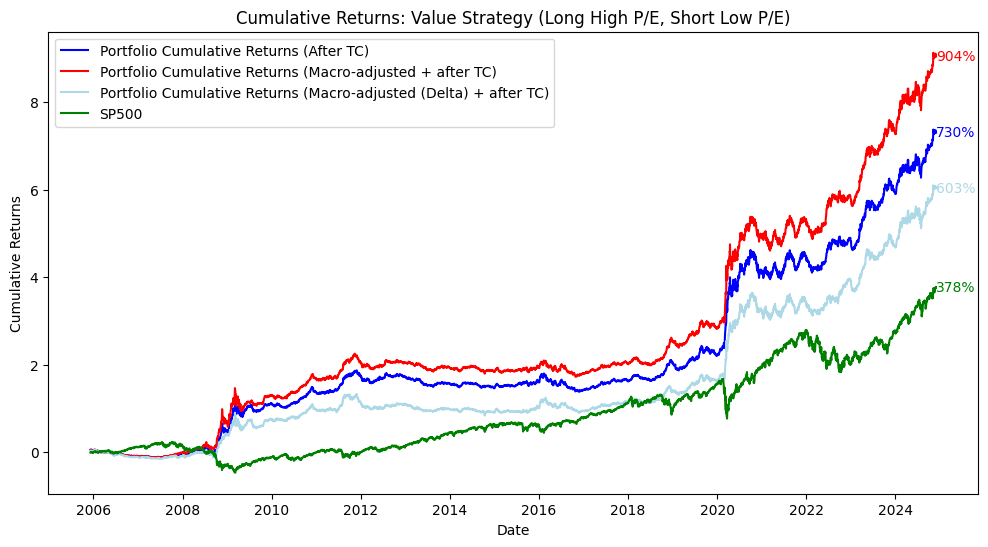

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Plotting the lines
plt.plot(portfolio_returns['Cumulative return (after TC)'], label='Portfolio Cumulative Returns (After TC)', color='blue')
plt.plot(portfolio_returns['Cumulative return (Macro-adjusted + after TC)'], label='Portfolio Cumulative Returns (Macro-adjusted + after TC)', color='red')
plt.plot(portfolio_returns['Cumulative return (Macro-adjusted (Delta) + after TC)'], label='Portfolio Cumulative Returns (Macro-adjusted (Delta) + after TC)', color='lightblue')
plt.plot(portfolio_returns['SP500_Cumulative_Returns'], label='SP500', color='green')

# Adding percentage end value labels with brackets for negatives
for column, color in zip(
    ['Cumulative return (after TC)', 'Cumulative return (Macro-adjusted + after TC)',
     'Cumulative return (Macro-adjusted (Delta) + after TC)', 'SP500_Cumulative_Returns'],
    ['blue', 'red', 'lightblue', 'green']
):
    end_value = portfolio_returns[column].iloc[-1]
    end_value_percentage = end_value * 100  # Convert to percentage

    # Format with brackets for negative values
    formatted_value = f'({abs(end_value_percentage):.0f}%)' if end_value < 0 else f'{end_value_percentage:.0f}%'

    plt.text(portfolio_returns.index[-1], end_value, formatted_value, color=color, fontsize=10, va='center')

# Adding title, labels, and legend
plt.title('Cumulative Returns: Value Strategy (Long High P/E, Short Low P/E)')
plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.legend()
plt.grid(False)  # Removes gridlines

plt.show()


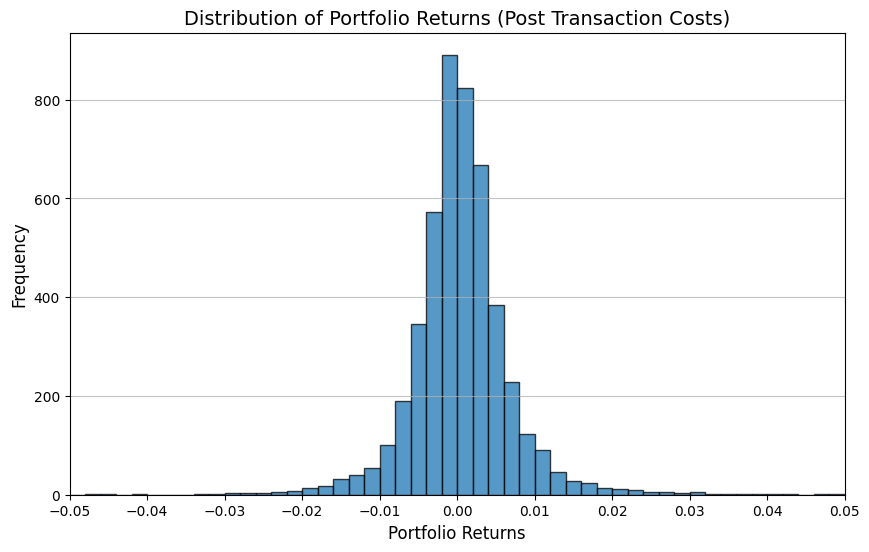

In [18]:
plt.figure(figsize=(10, 6))
plt.hist(portfolio_returns['portfolio returns (after TC)'], bins=50, alpha=0.75, edgecolor='black', range=(-0.05, 0.05))
plt.title('Distribution of Portfolio Returns (Post Transaction Costs)', fontsize=14)
plt.xlabel('Portfolio Returns', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(ticks=np.linspace(-0.05, 0.05, 11), fontsize=10)  # Adjust x-axis tick labels
plt.grid(axis='y', alpha=0.75)
plt.xlim(-0.05, 0.05)  # Limit x-axis range for clarity
plt.show()


In [19]:
# Function to calculate performance metrics
def calculate_metrics(returns, risk_free_rate):
    # Annualized Volatility
    volatility = returns.std() * np.sqrt(252)

    # Daily Metrics
    average_daily_return = returns.mean()
    median_daily_return = returns.median()
    quantile_25 = returns.quantile(0.25)
    quantile_75 = returns.quantile(0.75)

    # Annualized Excess Return
    excess_returns = returns - risk_free_rate
    average_excess_return = excess_returns.mean() * 252  # Annualized

    # Sharpe Ratio
    sharpe_ratio = average_excess_return / volatility

    return {
        "Average Daily Return": average_daily_return,
        "Median Daily Return": median_daily_return,
        "25% Quantile": quantile_25,
        "75% Quantile": quantile_75,
        "Volatility": volatility,
        "Sharpe Ratio": sharpe_ratio
    }

# Calculate metrics for portfolio returns
portfolio_metrics = calculate_metrics(
    portfolio_returns['portfolio returns (after TC)'],
    portfolio_returns['Risk_Free_Rate']
)

# Calculate metrics for macro-adjusted portfolio returns
portfolio_metrics_macro = calculate_metrics(
    portfolio_returns['portfolio returns (Macro-adjusted + after TC)'],
    portfolio_returns['Risk_Free_Rate']
)

portfolio_metrics_macro_delta = calculate_metrics(
    portfolio_returns['portfolio returns (Macro-adjusted (Delta) + after TC)'],
    portfolio_returns['Risk_Free_Rate']
)

# Calculate metrics for S&P500 returns
sp500_metrics = calculate_metrics(
    portfolio_returns['SP500_Returns'],
    portfolio_returns['Risk_Free_Rate']
)

# Create a DataFrame to store the results
performance_metrics = pd.DataFrame({
    "Metric": [
        "Average Daily Return",
        "Median Daily Return",
        "25% Quantile",
        "75% Quantile",
        "Volatility",
        "Sharpe Ratio"
    ],
    "Strategy": [portfolio_metrics[key] for key in portfolio_metrics.keys()],
    "Strategy_Macro": [portfolio_metrics_macro[key] for key in portfolio_metrics_macro.keys()],
    "Strategy_Macro_Delta": [portfolio_metrics_macro_delta[key] for key in portfolio_metrics_macro_delta.keys()],
    "S&P 500": [sp500_metrics[key] for key in sp500_metrics.keys()]
})

# Display the performance metrics DataFrame
performance_metrics


,Metric,Strategy,Strategy_Macro,Strategy_Macro_Delta,S&P 500
0,Average Daily Return,0.000456,0.000500,0.000430,0.000403
1,Median Daily Return,0.000273,0.000329,0.000288,0.000726
2,25% Quantile,-0.002659,-0.002637,-0.003114,-0.004073
3,75% Quantile,0.003268,0.003298,0.003684,0.005768
4,Volatility,0.109872,0.115593,0.119029,0.195228
5,Sharpe Ratio,0.910074,0.961427,0.785466,0.444362


## FACTOR: Book to Market


In [ ]:
start_date = '2000-01-01'
end_date = '2024-12-01'

closing_price = pd.DataFrame()  # To store market values (Close prices)
bm_ratio = pd.DataFrame()  # To store book-to-market values

for ticker in tickers:
    try:
        # Fetch stock price data
        stock_data = yf.download(ticker, start=start_date, end=end_date)
        stock = yf.Ticker(ticker)

        # Fetch book value per share and calculate B/M ratio
        book_value = stock.info.get('bookValue', None)
        if book_value is not None:
            book_to_market = book_value / stock_data['Close']  # B/M = Book Value / Market Value
            closing_price[ticker] = stock_data['Close']
            bm_ratio[ticker] = book_to_market
        else:
            print(f"Book value not available for {ticker}")
    except Exception as e:
        print(f"Error fetching data for {ticker}: {e}")

bm_ratio.head()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

Book value not available for BRK.B


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
$BF.B: possibly delisted; no price

Book value not available for BF.B


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

,MMM,AOS,ABT,ABBV,ACN,ADBE,AMD,AES,AFL,A,...,WMB,WTW,WDAY,WYNN,XEL,XYL,YUM,ZBRA,ZBH,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-03,0.324862,5.983516,3.716334,NaN,NaN,1.730296,2.493548,0.249626,8.847231,0.569094,...,1.198076,NaN,NaN,NaN,5.798414,NaN,-5.871757,2.890748,NaN,NaN
2000-01-04,0.338305,6.070992,3.825640,NaN,NaN,1.888741,2.642735,0.259934,9.088402,0.616162,...,1.225248,NaN,NaN,NaN,5.667904,NaN,-5.992200,2.933067,NaN,NaN
2000-01-05,0.328781,6.088792,3.832683,NaN,NaN,1.852123,2.576667,0.257164,9.140863,0.656910,...,1.153875,NaN,NaN,NaN,5.457333,NaN,-5.961633,2.877971,NaN,NaN
2000-01-06,0.304306,6.179403,3.703110,NaN,NaN,1.837126,2.415625,0.255124,8.959851,0.682913,...,1.129745,NaN,NaN,NaN,5.508492,NaN,-6.012759,3.042715,NaN,NaN
2000-01-07,0.298383,5.932228,3.663992,NaN,NaN,1.752008,2.378462,0.250273,8.785878,0.630381,...,1.100455,NaN,NaN,NaN,5.508492,NaN,-6.149889,3.076862,NaN,NaN


In [ ]:
bm_ratio = bm_ratio.dropna(axis=1)

# Step 1: Rank stocks by Book-to-Market ratio daily
# Higher Book-to-Market values get higher ranks (e.g., rank 1 is the highest B/M ratio)
ranked_bm = bm_ratio.rank(axis=1, ascending=False, method='min')

# Step 2: Normalize the ranks to create Value Factor Scores (scale to 0-1)
# Divide each rank by the maximum rank for the day to scale between 0 and 1
bm_factor_scores = ranked_bm.div(ranked_bm.max(axis=1), axis=0)

# Step 3: Save the Value Factor Scores to a CSV file (optional)
#bm_factor_scores.to_csv('value_factor_scores.csv')
bm_factor_scores.index = pd.to_datetime(bm_factor_scores.index).strftime('%Y-%m-%d')

# Display the resulting Value Factor Scores DataFrame
cols_hightolow = bm_factor_scores.iloc[-1].sort_values(ascending=False).index.tolist()
bm_factor_scores = bm_factor_scores[cols_hightolow]
bm_factor_scores




,SBAC,YUM,VRSN,CAH,SBUX,LOW,DVA,AZO,BKNG,MAR,...,EG,AIG,VTRS,CVS,L,TFC,BEN,IVZ,MOS,C
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-03,0.985591,1.000000,0.956772,0.965418,0.988473,0.982709,0.991354,0.997118,0.968300,0.974063,...,0.037464,0.936599,0.726225,0.403458,0.170029,0.420749,0.438040,0.636888,0.515850,0.864553
2000-01-04,0.985591,1.000000,0.956772,0.965418,0.988473,0.982709,0.991354,0.997118,0.968300,0.974063,...,0.037464,0.936599,0.717579,0.406340,0.170029,0.403458,0.438040,0.639769,0.512968,0.861671
2000-01-05,0.985591,1.000000,0.956772,0.965418,0.988473,0.982709,0.991354,0.997118,0.968300,0.974063,...,0.040346,0.936599,0.731988,0.429395,0.167147,0.406340,0.440922,0.625360,0.533141,0.873199
2000-01-06,0.985591,0.997118,0.956772,0.965418,0.988473,0.979827,0.991354,1.000000,0.968300,0.974063,...,0.043228,0.936599,0.731988,0.391931,0.164265,0.420749,0.446686,0.622478,0.541787,0.873199
2000-01-07,0.985591,1.000000,0.956772,0.965418,0.988473,0.979827,0.991354,0.997118,0.968300,0.974063,...,0.046110,0.936599,0.731988,0.389049,0.161383,0.414986,0.443804,0.631124,0.536023,0.870317
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-11-22,1.000000,0.997118,0.994236,0.991354,0.988473,0.985591,0.982709,0.979827,0.976945,0.974063,...,0.031700,0.023055,0.025937,0.014409,0.017291,0.020173,0.011527,0.008646,0.005764,0.002882
2024-11-25,1.000000,0.997118,0.994236,0.991354,0.988473,0.985591,0.982709,0.979827,0.976945,0.974063,...,0.028818,0.023055,0.025937,0.020173,0.014409,0.017291,0.011527,0.008646,0.005764,0.002882
2024-11-26,1.000000,0.997118,0.994236,0.991354,0.988473,0.985591,0.982709,0.979827,0.976945,0.974063,...,0.028818,0.025937,0.023055,0.014409,0.020173,0.017291,0.011527,0.008646,0.005764,0.002882


In [ ]:
# Step 1: Identify the top 10 ranked (highest ranks) and bottom 10 ranked (lowest ranks) stocks for each day
top_10_bm = ranked_bm.apply(lambda row: row.nlargest(17).index.tolist(), axis=1)
bottom_10_bm = ranked_bm.apply(lambda row: row.nsmallest(17).index.tolist(), axis=1)

# Step 2: Create a DataFrame to store the portfolio
portfolios_bm = pd.DataFrame(index=ranked_bm.index, columns=['Top10_long', 'Bottom10_short'])

# Assign the lists of stocks to long and short for each day
portfolios_bm['Top10_long'] = top_10_bm
portfolios_bm['Bottom10_short'] = bottom_10_bm

# Step 3: Save the portfolio to a CSV file (optional)
#portfolios_bm.to_csv('portfolio_bm.csv')
portfolios_bm.index = portfolios_bm.index.date
portfolios_bm.index = pd.to_datetime(portfolios_bm.index)
# Display the resulting portfolio
portfolios_bm.head()

,Top10_long,Bottom10_short
2000-01-03,"[YUM, AZO, FICO, DVA, SBUX, SBAC, LOW, MO, ORL...","[MNST, DECK, NVDA, ACGL, ODFL, BLK, VLO, WRB, ..."
2000-01-04,"[YUM, AZO, FICO, DVA, SBUX, SBAC, LOW, ORLY, M...","[MNST, DECK, NVDA, ACGL, ODFL, BLK, VLO, WRB, ..."
2000-01-05,"[YUM, AZO, FICO, DVA, SBUX, SBAC, LOW, ORLY, M...","[MNST, DECK, NVDA, ACGL, ODFL, BLK, WRB, VLO, ..."
2000-01-06,"[AZO, YUM, FICO, DVA, SBUX, SBAC, ORLY, LOW, M...","[MNST, DECK, NVDA, ACGL, ODFL, BLK, DHI, WRB, ..."
2000-01-07,"[YUM, AZO, FICO, DVA, SBUX, SBAC, ORLY, LOW, M...","[MNST, DECK, NVDA, ACGL, ODFL, BLK, WRB, DHI, ..."


In [ ]:
factor_scores = pd.read_excel("Factor.xlsm")


factor_scores['date'] = pd.to_datetime(factor_scores['date'])  # Ensure 'date' is in datetime format
factor_scores.set_index('date', inplace=True)  # Set 'date' as the index

# Generate a daily date range covering the full period
daily_index = pd.date_range(start='2005-01-01', end='2024-12-31', freq='D')

# Backfill first to assign each month's last value to earlier dates
# Then reindex to daily, ensuring January gets the value of January 31
monthly_factor_scores = factor_scores.resample('ME').ffill()
daily_factor_scores = monthly_factor_scores.resample('D').bfill()

# Reset the index for integration with other datasets
daily_factor_scores = daily_factor_scores.reindex(daily_index, method='bfill').reset_index()

# Rename columns for clarity
daily_factor_scores.rename(columns={'index': 'date'}, inplace=True)

daily_factor_scores['regime'] = daily_factor_scores['z-score'].apply(
    lambda x: 'expansion' if x > 0 else ('contraction' if x < -0.5 else 'neutral')
)

daily_factor_scores.index = daily_factor_scores.date
daily_factor_scores.index = pd.to_datetime(daily_factor_scores.index)

daily_factor_scores['prev_regime'] = daily_factor_scores['regime'].shift(1)

daily_factor_scores['long_weight'] = daily_factor_scores['prev_regime'].apply(lambda x: 1.2 if x=='expansion' else (0.8 if x=='contraction' else 1.0))
daily_factor_scores['short_weight'] = daily_factor_scores['prev_regime'].apply(lambda x: 0.8 if x=='expansion' else (1.2 if x=='contraction' else 1.0))

daily_factor_scores.head()

,date,factor,square,vol,z-score,regime,prev_regime,long_weight,short_weight
date,,,,,,,,,
2005-01-01,2005-01-01,0.502212,0.252217,0.502212,1.0,expansion,NaN,1.0,1.0
2005-01-02,2005-01-02,0.502212,0.252217,0.502212,1.0,expansion,expansion,1.2,0.8
2005-01-03,2005-01-03,0.502212,0.252217,0.502212,1.0,expansion,expansion,1.2,0.8
2005-01-04,2005-01-04,0.502212,0.252217,0.502212,1.0,expansion,expansion,1.2,0.8
2005-01-05,2005-01-05,0.502212,0.252217,0.502212,1.0,expansion,expansion,1.2,0.8


In [25]:
# Calculate long and short returns

stock_returns_test = stock_returns.loc['2005-01-01':]

long_returns_delta = stock_returns_test.apply(
    lambda row: row[portfolios_bm.loc[row.name, 'Top10_long']].mean()*daily_factor_scores_delta.loc[row.name,'long_weight']
    if portfolios_bm.loc[row.name, 'Top10_long'] else 0,
    axis=1
)

short_returns_delta = stock_returns_test.apply(
    lambda row: -row[portfolios_bm.loc[row.name, 'Bottom10_short']].mean()*daily_factor_scores_delta.loc[row.name,'short_weight']
    if portfolios_bm.loc[row.name, 'Bottom10_short'] else 0,
    axis=1
)

long_returns_macro = stock_returns_test.apply(
    lambda row: row[portfolios_bm.loc[row.name, 'Top10_long']].mean()*daily_factor_scores.loc[row.name,'long_weight']
    if portfolios_bm.loc[row.name, 'Top10_long'] else 0,
    axis=1
)

short_returns_macro = stock_returns_test.apply(
    lambda row: -row[portfolios_bm.loc[row.name, 'Bottom10_short']].mean()*daily_factor_scores.loc[row.name,'short_weight']
    if portfolios_bm.loc[row.name, 'Bottom10_short'] else 0,
    axis=1
)

long_returns = stock_returns_test.apply(
    lambda row: row[portfolios_bm.loc[row.name, 'Top10_long']].mean()
    if portfolios_bm.loc[row.name, 'Top10_long'] else 0,
    axis=1
)

short_returns = stock_returns_test.apply(
    lambda row: -row[portfolios_bm.loc[row.name, 'Bottom10_short']].mean()
    if portfolios_bm.loc[row.name, 'Bottom10_short'] else 0,
    axis=1
)

portfolio_returns = long_returns/2 - short_returns/2 #transaction cost
portfolio_returns = portfolio_returns.fillna(0)  # Handle any missing values

portfolio_returns = portfolio_returns.to_frame(name='portfolio returns (before TC)')
portfolio_returns['portfolio returns (after TC)'] = long_returns/2 + short_returns/2 - 0.00015
portfolio_returns['portfolio returns (Macro-adjusted + after TC)'] = long_returns_macro/2 + short_returns_macro/2 - 0.00015
portfolio_returns['portfolio returns (Macro-adjusted (Delta) + after TC)'] = long_returns_delta/2 + short_returns_delta/2 - 0.00015
portfolio_returns['Cumulative return (before TC)'] = (1 + portfolio_returns['portfolio returns (before TC)']).cumprod() - 1
portfolio_returns['Cumulative return (after TC)'] = (1 + portfolio_returns['portfolio returns (after TC)']).cumprod() - 1
portfolio_returns['Cumulative return (Macro-adjusted + after TC)'] = (1 + portfolio_returns['portfolio returns (Macro-adjusted + after TC)']).cumprod() - 1
portfolio_returns['Cumulative return (Macro-adjusted (Delta) + after TC)'] = (1 + portfolio_returns['portfolio returns (Macro-adjusted (Delta) + after TC)']).cumprod() - 1
portfolio_returns.index = pd.to_datetime(portfolio_returns.index)
market_data.index = pd.to_datetime(market_data.index)

portfolio_returns = portfolio_returns.join(market_data, how='inner')

portfolio_returns['SP500_Cumulative_Returns'] = (1 + portfolio_returns['SP500_Returns']).cumprod() - 1

portfolio_returns

,portfolio returns (before TC),portfolio returns (after TC),portfolio returns (Macro-adjusted + after TC),portfolio returns (Macro-adjusted (Delta) + after TC),Cumulative return (before TC),Cumulative return (after TC),Cumulative return (Macro-adjusted + after TC),Cumulative return (Macro-adjusted (Delta) + after TC),SP500_Returns,Risk_Free_Rate,Excess_Returns,SP500_Cumulative_Returns
Date,,,,,,,,,,,,
2005-12-07,-0.000935,0.000492,0.000305,0.000679,0.035839,0.073211,0.082024,0.063364,-0.005009,0.000156,-0.005165,-0.005009
2005-12-08,0.000855,0.000588,0.000759,0.000417,0.036724,0.073842,0.082845,0.063807,-0.001217,0.000153,-0.001369,-0.006220
2005-12-09,0.004211,-0.002789,-0.001947,-0.003631,0.041090,0.070847,0.080738,0.059944,0.002811,0.000152,0.002658,-0.003426
2005-12-12,-0.004316,0.000624,-0.000239,0.001487,0.036597,0.071515,0.080479,0.061520,0.000842,0.000152,0.000690,-0.002588
2005-12-13,0.001241,-0.001298,-0.001049,-0.001546,0.037883,0.070125,0.079345,0.059879,0.005554,0.000152,0.005402,0.002952
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-11-22,0.005503,-0.005126,-0.005126,-0.005126,0.529919,2.339064,3.275015,1.931324,0.003468,0.000175,0.003293,3.725876
2024-11-25,0.002516,-0.001012,-0.001012,-0.001012,0.533767,2.335685,3.270689,1.928357,0.003020,0.000175,0.002846,3.740151
2024-11-26,0.000824,0.005328,0.005328,0.005328,0.535031,2.353457,3.293442,1.943958,0.005722,0.000174,0.005548,3.767274


In [26]:
short_returns

Date
2005-01-03    0.015578
2005-01-04    0.027932
2005-01-05    0.009152
2005-01-06    0.006955
2005-01-07    0.004262
                ...   
2024-11-22   -0.010479
2024-11-25   -0.003378
2024-11-26    0.004654
2024-11-27   -0.002295
2024-11-29   -0.001016
Length: 5012, dtype: float64

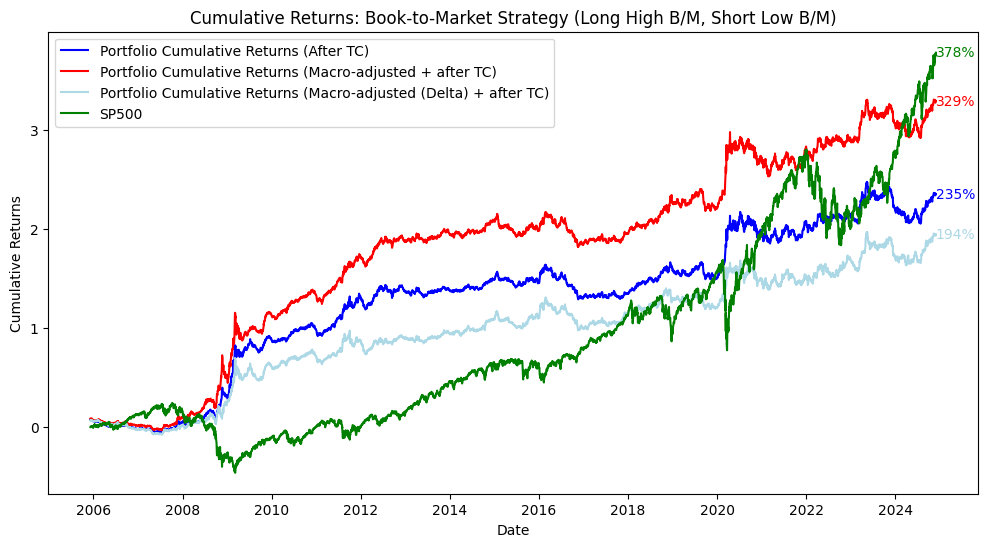

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Plotting the lines
plt.plot(portfolio_returns['Cumulative return (after TC)'], label='Portfolio Cumulative Returns (After TC)', color='blue')
plt.plot(portfolio_returns['Cumulative return (Macro-adjusted + after TC)'], label='Portfolio Cumulative Returns (Macro-adjusted + after TC)', color='red')
plt.plot(portfolio_returns['Cumulative return (Macro-adjusted (Delta) + after TC)'], label='Portfolio Cumulative Returns (Macro-adjusted (Delta) + after TC)', color='lightblue')
plt.plot(portfolio_returns['SP500_Cumulative_Returns'], label='SP500', color='green')

# Adding percentage end value labels with brackets for negatives
for column, color in zip(
    ['Cumulative return (after TC)', 'Cumulative return (Macro-adjusted + after TC)',
     'Cumulative return (Macro-adjusted (Delta) + after TC)', 'SP500_Cumulative_Returns'],
    ['blue', 'red', 'lightblue', 'green']
):
    end_value = portfolio_returns[column].iloc[-1]
    end_value_percentage = end_value * 100  # Convert to percentage

    # Format with brackets for negative values
    formatted_value = f'({abs(end_value_percentage):.0f}%)' if end_value < 0 else f'{end_value_percentage:.0f}%'

    plt.text(portfolio_returns.index[-1], end_value, formatted_value, color=color, fontsize=10, va='center')

# Adding title, labels, and legend
plt.title('Cumulative Returns: Book-to-Market Strategy (Long High B/M, Short Low B/M)')
plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.legend()
plt.grid(False)  # Removes gridlines

plt.show()

In [28]:
stock_returns_test = stock_returns.loc['2005-01-01':]
stock_returns_test.index = pd.to_datetime(stock_returns_test.index)

long_returns_bm = stock_returns_test.apply(
    lambda row: row[portfolios_bm.loc[row.name, 'Top10_long']].mean()
    if portfolios_bm.loc[row.name, 'Top10_long'] else 0,
    axis=1
)

short_returns_bm = stock_returns_test.apply(
    lambda row: -row[portfolios_bm.loc[row.name, 'Bottom10_short']].mean()
    if portfolios_bm.loc[row.name, 'Bottom10_short'] else 0,
    axis=1
)

portfolio_returns_bm = long_returns_bm/2 - short_returns_bm/2 #transaction cost
portfolio_returns_bm = portfolio_returns_bm.fillna(0)  # Handle any missing values

portfolio_returns_bm = portfolio_returns_bm.to_frame(name='portfolio returns (before TC)')
portfolio_returns_bm['portfolio returns (after TC)'] = long_returns_bm/2 + short_returns_bm/2 - 0.00015
portfolio_returns_bm['Cumulative return (before TC)'] = (1 + portfolio_returns_bm['portfolio returns (before TC)']).cumprod() - 1
portfolio_returns_bm['Cumulative return (after TC)'] = (1 + portfolio_returns_bm['portfolio returns (after TC)']).cumprod() - 1
portfolio_returns_bm['Long (after TC)'] = long_returns_bm - 0.00015
portfolio_returns_bm['Long Cumulative return (after TC)'] = (1 + portfolio_returns_bm['Long (after TC)']).cumprod() - 1
portfolio_returns_bm['Short (after TC)'] = -short_returns_bm - 0.00015
portfolio_returns_bm['Short Cumulative return (after TC)'] = (1 + portfolio_returns_bm['Short (after TC)']).cumprod() - 1

portfolio_returns_bm.index = pd.to_datetime(portfolio_returns_bm.index)
market_data.index = pd.to_datetime(market_data.index)

portfolio_returns_bm.index = portfolio_returns_bm.index.tz_localize(None)
market_data.index = market_data.index.tz_localize(None)

portfolio_returns_bm = portfolio_returns_bm.join(market_data, how='inner')

portfolio_returns_bm['SP500_Cumulative_Returns'] = (1 + portfolio_returns_bm['SP500_Returns']).cumprod() - 1

In [29]:
portfolio_returns_bm

,portfolio returns (before TC),portfolio returns (after TC),Cumulative return (before TC),Cumulative return (after TC),Long (after TC),Long Cumulative return (after TC),Short (after TC),Short Cumulative return (after TC),SP500_Returns,Risk_Free_Rate,Excess_Returns,SP500_Cumulative_Returns
Date,,,,,,,,,,,,
2005-12-07,-0.000935,0.000492,0.035839,0.073211,-0.000443,0.115392,-0.001727,-0.106368,-0.005009,0.000156,-0.005165,-0.005009
2005-12-08,0.000855,0.000588,0.036724,0.073842,0.001443,0.117001,-0.000033,-0.106397,-0.001217,0.000153,-0.001369,-0.006220
2005-12-09,0.004211,-0.002789,0.041090,0.070847,0.001423,0.118590,0.006700,-0.100410,0.002811,0.000152,0.002658,-0.003426
2005-12-12,-0.004316,0.000624,0.036597,0.071515,-0.003692,0.114460,-0.005240,-0.105124,0.000842,0.000152,0.000690,-0.002588
2005-12-13,0.001241,-0.001298,0.037883,0.070125,-0.000057,0.114397,0.002239,-0.103121,0.005554,0.000152,0.005402,0.002952
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-11-22,0.005503,-0.005126,0.529919,2.339064,0.000376,4.946478,0.010329,-0.921947,0.003468,0.000175,0.003293,3.725876
2024-11-25,0.002516,-0.001012,0.533767,2.335685,0.001504,4.955419,0.003228,-0.921695,0.003020,0.000175,0.002846,3.740151
2024-11-26,0.000824,0.005328,0.535031,2.353457,0.006151,4.992053,-0.004804,-0.922071,0.005722,0.000174,0.005548,3.767274


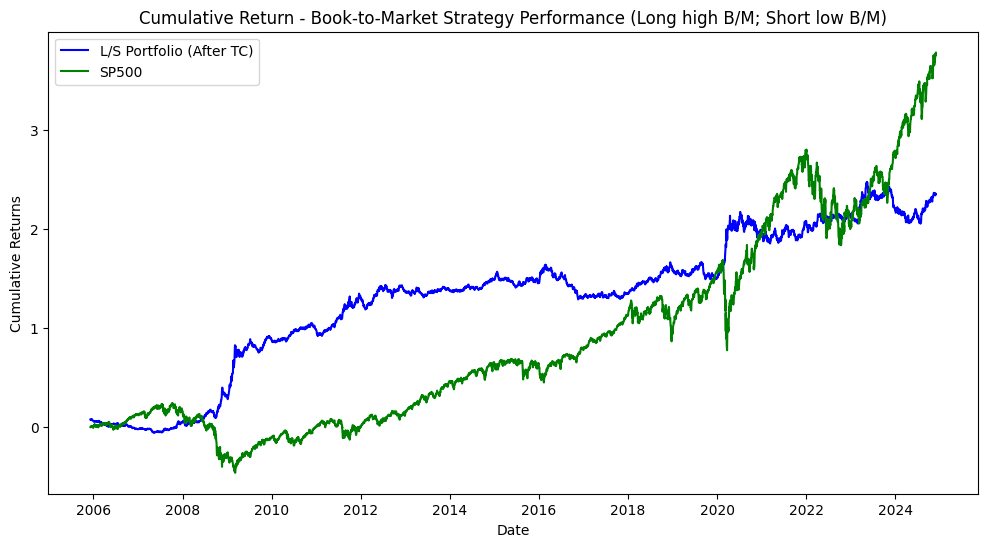

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(portfolio_returns_bm['Cumulative return (after TC)'], label='L/S Portfolio (After TC)', color='blue')
plt.plot(portfolio_returns_bm['SP500_Cumulative_Returns'], label='SP500', color='green')
plt.title('Cumulative Return - Book-to-Market Strategy Performance (Long high B/M; Short low B/M)')
plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.legend()
plt.show()


## Factor: Market Cap

In [31]:
# Initialize DataFrames for market caps, weekly close prices, and weekly market data
market_caps = pd.DataFrame()
weekly_prices = pd.DataFrame()
weekly_market_data = pd.DataFrame()

# Define the ticker for S&P 500
sp500_ticker = "^GSPC"

# Loop through each ticker
for ticker in tickers + [sp500_ticker]:  # Add S&P 500 ticker to the tickers list
    # Download historical data
    print(f"Processing {ticker}")
    stock_data = yf.Ticker(ticker)
    hist = stock_data.history(start="2000-01-01", end="2024-12-01")  # Full available history
    hist.index = pd.to_datetime(hist.index).tz_localize(None)

    if ticker == sp500_ticker:
        # For S&P 500, only resample weekly close prices
        weekly_sp500_data = hist['Close'].resample('W').last()
        weekly_sp500_data.name = ticker
        weekly_market_data = pd.concat([weekly_market_data, weekly_sp500_data], axis=1)
        continue

    # Get shares outstanding for other tickers
    shares_outstanding = stock_data.info.get("sharesOutstanding", None)
    if shares_outstanding is None:
        print(f"Shares outstanding not available for {ticker}. Skipping.")
        continue

    # Calculate market cap
    hist['Market Cap'] = hist['Close'] * shares_outstanding

    # Resample to weekly frequency (last value of the week for both market cap and close price)
    weekly_market_cap = hist['Market Cap'].resample('W').last()
    weekly_market_cap.name = ticker  # Name the Series with the ticker

    weekly_close_price = hist['Close'].resample('W').last()
    weekly_close_price.name = ticker  # Name the Series with the ticker

    # Append to the main DataFrames
    market_caps = pd.concat([market_caps, weekly_market_cap], axis=1)
    weekly_prices = pd.concat([weekly_prices, weekly_close_price], axis=1)

# Format indices for all DataFrames
market_caps.index = pd.to_datetime(market_caps.index)
market_caps.index = market_caps.index.to_series().dt.strftime('%Y-%m-%d')

weekly_prices.index = pd.to_datetime(weekly_prices.index)
weekly_prices.index = weekly_prices.index.to_series().dt.strftime('%Y-%m-%d')

weekly_market_data.index = pd.to_datetime(weekly_market_data.index)
weekly_market_data.index = weekly_market_data.index.to_series().dt.strftime('%Y-%m-%d')

weekly_returns = weekly_prices.pct_change()

weekly_market_data.head()


Processing MMM
Processing AOS
Processing ABT
Processing ABBV
Processing ACN
Processing ADBE
Processing AMD
Processing AES
Processing AFL
Processing A
Processing APD
Processing ABNB
Processing AKAM
Processing ALB
Processing ARE
Processing ALGN
Processing ALLE
Processing LNT
Processing ALL
Processing GOOGL
Processing GOOG
Processing MO
Processing AMZN
Processing AMCR
Processing AEE
Processing AEP
Processing AXP
Processing AIG
Processing AMT
Processing AWK
Processing AMP
Processing AME
Processing AMGN
Processing APH
Processing ADI
Processing AON
Processing APA
Processing APO
Processing AAPL
Processing AMAT
Processing APP
Processing APTV
Processing ACGL
Processing ADM
Processing ARES
Processing ANET
Processing AJG
Processing AIZ
Processing T
Processing ATO
Processing ADSK
Processing ADP
Processing AZO
Processing AVB
Processing AVY
Processing AXON
Processing BKR
Processing BALL
Processing BAC
Processing BAX
Processing BDX


$BRK.B: possibly delisted; no timezone found


Processing BRK.B
Shares outstanding not available for BRK.B. Skipping.
Processing BBY
Processing TECH
Processing BIIB
Processing BLK
Processing BX
Processing XYZ
Processing BK
Processing BA
Processing BKNG
Processing BSX
Processing BMY
Processing AVGO
Processing BR
Processing BRO


$BF.B: possibly delisted; no price data found  (1d 2000-01-01 -> 2024-12-01)


Processing BF.B
Shares outstanding not available for BF.B. Skipping.
Processing BLDR
Processing BG
Processing BXP
Processing CHRW
Processing CDNS
Processing CPT
Processing CPB
Processing COF
Processing CAH
Processing CCL
Processing CARR
Processing CVNA
Processing CASY
Processing CAT
Processing CBOE
Processing CBRE
Processing CDW
Processing COR
Processing CNC
Processing CNP
Processing CF
Processing CRL
Processing SCHW
Processing CHTR
Processing CVX
Processing CMG
Processing CB
Processing CHD
Processing CIEN
Processing CI
Processing CINF
Processing CTAS
Processing CSCO
Processing C
Processing CFG
Processing CLX
Processing CME
Processing CMS
Processing KO
Processing CTSH
Processing COHR
Processing COIN
Processing CL
Processing CMCSA
Processing FIX
Processing CAG
Processing COP
Processing ED
Processing STZ
Processing CEG
Processing COO
Processing CPRT
Processing GLW
Processing CPAY
Processing CTVA
Processing CSGP
Processing COST
Processing CTRA
Processing CRH
Processing CRWD
Processing CCI

$Q: possibly delisted; no price data found  (1d 2000-01-01 -> 2024-12-01) (Yahoo error = "Data doesn't exist for startDate = 946702800, endDate = 1733029200")


Processing Q
Processing RL
Processing RJF
Processing RTX
Processing O
Processing REG
Processing REGN
Processing RF
Processing RSG
Processing RMD
Processing RVTY
Processing HOOD
Processing ROK
Processing ROL
Processing ROP
Processing ROST
Processing RCL
Processing SPGI
Processing CRM


$SNDK: possibly delisted; no price data found  (1d 2000-01-01 -> 2024-12-01) (Yahoo error = "Data doesn't exist for startDate = 946702800, endDate = 1733029200")


Processing SNDK
Processing SBAC
Processing SLB
Processing STX
Processing SRE
Processing NOW
Processing SHW
Processing SPG
Processing SWKS
Processing SJM
Processing SW
Processing SNA
Processing SOLV
Processing SO
Processing LUV
Processing SWK
Processing SBUX
Processing STT
Processing STLD
Processing STE
Processing SYK
Processing SMCI
Processing SYF
Processing SNPS
Processing SYY
Processing TMUS
Processing TROW
Processing TTWO
Processing TPR
Processing TRGP
Processing TGT
Processing TEL
Processing TDY
Processing TER
Processing TSLA
Processing TXN
Processing TPL
Processing TXT
Processing TMO
Processing TJX
Processing TKO
Processing TTD
Processing TSCO
Processing TT
Processing TDG
Processing TRV
Processing TRMB
Processing TFC
Processing TYL
Processing TSN
Processing USB
Processing UBER
Processing UDR
Processing ULTA
Processing UNP
Processing UAL
Processing UPS
Processing URI
Processing UNH
Processing UHS
Processing VLO
Processing VTR
Processing VLTO
Processing VRSN
Processing VRSK
Processi

,^GSPC
2000-01-09,1441.469971
2000-01-16,1465.150024
2000-01-23,1441.359985
2000-01-30,1360.160034
2000-02-06,1424.369995


In [32]:
weekly_returns = weekly_prices.pct_change()
weekly_returns.head()

,MMM,AOS,ABT,ABBV,ACN,ADBE,AMD,AES,AFL,A,...,WMB,WTW,WDAY,WYNN,XEL,XYL,YUM,ZBRA,ZBH,ZTS
2000-01-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-16,-0.033455,0.000000,-0.023391,NaN,NaN,0.024131,0.242308,0.151253,-0.047156,0.051923,...,0.035185,NaN,NaN,NaN,0.021875,NaN,0.010526,0.132900,NaN,NaN
2000-01-23,-0.044052,0.020000,-0.096015,NaN,NaN,-0.051838,-0.061920,-0.039039,-0.097526,0.005484,...,0.121647,NaN,NaN,NaN,-0.033639,NaN,-0.114583,0.049009,NaN,NaN
2000-01-30,-0.028308,-0.104109,0.022044,NaN,NaN,-0.084493,-0.069307,-0.045313,0.083871,-0.010000,...,-0.035088,NaN,NaN,NaN,-0.025316,NaN,-0.094117,-0.012923,NaN,NaN
2000-02-06,-0.034553,-0.050315,0.080392,NaN,NaN,0.285559,0.093972,-0.014730,0.046131,0.120294,...,-0.006612,NaN,NaN,NaN,0.003247,NaN,0.025974,0.066465,NaN,NaN


In [33]:
market_caps.rank(axis=1, ascending=True, method='average')

,MMM,AOS,ABT,ABBV,ACN,ADBE,AMD,AES,AFL,A,...,WMB,WTW,WDAY,WYNN,XEL,XYL,YUM,ZBRA,ZBH,ZTS
2000-01-09,272.0,14.0,286.0,NaN,NaN,246.0,310.0,293.0,183.0,274.0,...,278.0,NaN,NaN,NaN,207.0,NaN,92.0,86.0,NaN,NaN
2000-01-16,270.0,14.0,281.0,NaN,NaN,244.0,314.0,295.0,182.0,275.0,...,276.0,NaN,NaN,NaN,204.0,NaN,96.0,100.0,NaN,NaN
2000-01-23,267.0,15.0,276.0,NaN,NaN,242.0,313.0,297.0,171.0,271.0,...,278.0,NaN,NaN,NaN,206.0,NaN,78.0,99.0,NaN,NaN
2000-01-30,270.0,13.0,280.0,NaN,NaN,238.0,311.0,296.0,181.0,275.0,...,283.0,NaN,NaN,NaN,208.0,NaN,78.0,104.0,NaN,NaN
2000-02-06,267.0,12.0,285.0,NaN,NaN,253.0,314.0,296.0,182.0,278.0,...,280.0,NaN,NaN,NaN,209.0,NaN,77.0,109.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-11-03,354.0,11.0,463.0,478.0,467.0,462.0,470.0,24.0,328.0,260.0,...,342.0,199.0,316.0,26.0,268.0,201.0,244.0,123.0,133.0,368.0
2024-11-10,351.0,8.0,460.0,478.0,468.0,461.0,470.0,16.0,316.0,250.0,...,344.0,197.0,317.0,13.0,266.0,196.0,238.0,121.0,129.0,358.0
2024-11-17,346.0,7.0,459.0,475.0,467.0,462.0,469.0,15.0,324.0,243.0,...,345.0,198.0,319.0,18.0,267.0,195.0,245.0,114.0,140.0,358.0
2024-11-24,340.0,8.0,457.0,475.0,466.0,464.0,469.0,11.0,322.0,245.0,...,353.0,194.0,324.0,16.0,268.0,196.0,239.0,111.0,131.0,358.0


In [34]:
import numpy as np

# Step 1: Rank stocks by market cap weekly
ranked_market_caps = market_caps.rank(axis=1, ascending=True, method='average')

# Step 2: Identify small-cap and big-cap groups
# Convert median_rank to a DataFrame with the same shape as ranked_market_caps for broadcasting
median_rank_broadcasted = ranked_market_caps.median(axis=1)
median_rank_broadcasted = pd.DataFrame(
    np.tile(median_rank_broadcasted.values, (ranked_market_caps.shape[1], 1)).T,
    index=ranked_market_caps.index,
    columns=ranked_market_caps.columns
)

# Small-cap group: stocks with rank <= median rank
small_cap = ranked_market_caps[ranked_market_caps <= median_rank_broadcasted]

# Big-cap group: stocks with rank > median rank
big_cap = ranked_market_caps[ranked_market_caps > median_rank_broadcasted]

# Step 3: Calculate weekly returns for small-cap and big-cap portfolios
# Calculate weekly returns
weekly_returns = weekly_prices.pct_change()
weekly_market_returns = weekly_market_data.pct_change()

# Calculate the average weekly return for each group
small_cap_returns = weekly_returns[small_cap.notna()].mean(axis=1)  # Small-cap portfolio returns
big_cap_returns = weekly_returns[big_cap.notna()].mean(axis=1)  # Big-cap portfolio returns

# Step 4: Calculate SMB factor
smb_factor = small_cap_returns - big_cap_returns

# Convert to a DataFrame for better readability
smb_df = pd.DataFrame({'SMB Returns': smb_factor})
smb_df.dropna(inplace=True)  # Drop any rows with NaN values

# Display the SMB DataFrame to the user

# Save the SMB factor to a CSV file for reference
# smb_df.to_csv('SMB_factor.csv')

# See SMB factor scores
(smb_df['SMB Returns'] > 0).mean() * 100

smb_df

,SMB Returns
2000-01-16,-0.009642
2000-01-23,-0.001143
2000-01-30,-0.006568
2000-02-06,-0.022969
2000-02-13,-0.009825
...,...
2024-11-03,-0.003503
2024-11-10,-0.013317
2024-11-17,-0.008221
2024-11-24,0.004500


In [35]:
# Step 1: Rank stocks by market cap
ranked_market_caps = market_caps.rank(axis=1, ascending=True, method='min')  # Smaller cap gets higher rank

# Step 2: Define Long and Short Groups (Top 10% Small Cap, Bottom 10% Big Cap)
top_10_percentile = ranked_market_caps.quantile(0.1, axis=1)  # Threshold for top 10%
bottom_10_percentile = ranked_market_caps.quantile(0.9, axis=1)  # Threshold for bottom 10%

# Long portfolio: Small-cap stocks (market cap <= 10th percentile)
long_stocks = ranked_market_caps.apply(lambda row: row[row <= top_10_percentile[row.name]].index.tolist(), axis=1)

# Short portfolio: Big-cap stocks (market cap >= 90th percentile)
short_stocks = ranked_market_caps.apply(lambda row: row[row >= bottom_10_percentile[row.name]].index.tolist(), axis=1)

# Step 3: Create a DataFrame to store the portfolios
portfolios = pd.DataFrame(index=market_caps.index, columns=['Top10_long', 'Bottom10_short'])
portfolios['Top10_long'] = long_stocks
portfolios['Bottom10_short'] = short_stocks

# Save the portfolios to a CSV file
#portfolios.to_csv('SMB_long_short_portfolios.csv')

# Display the resulting portfolio data
portfolios_marketcap = portfolios
portfolios_marketcap

,Top10_long,Bottom10_short
2000-01-09,"[AOS, AME, ACGL, AZO, BALL, CASY, COHR, FIX, D...","[AKAM, AMZN, AIG, T, BAC, BMY, CCL, SCHW, CVX,..."
2000-01-16,"[AOS, AME, ACGL, AZO, BALL, CASY, COHR, FIX, D...","[AMD, AKAM, AMZN, AIG, T, BAC, BMY, CCL, SCHW,..."
2000-01-23,"[AOS, AME, AZO, BALL, CASY, COHR, FIX, DVA, DE...","[AMD, AKAM, AMZN, AIG, T, BAC, BMY, CCL, SCHW,..."
2000-01-30,"[AOS, AZO, BALL, BRO, CASY, COHR, FIX, DVA, DE...","[AKAM, AMZN, AIG, T, BAC, BMY, CCL, SCHW, CVX,..."
2000-02-06,"[AOS, AME, ACGL, AZO, BALL, CASY, COHR, FIX, D...","[AMD, AKAM, AMZN, AIG, T, BAC, BMY, CCL, SCHW,..."
...,...,...
2024-11-03,"[AOS, AES, ALB, ALLE, APA, APTV, AIZ, TECH, BX...","[ABT, ABBV, ACN, ADBE, AMD, GOOGL, GOOG, AMZN,..."
2024-11-10,"[AOS, AES, ALB, ALLE, APA, APTV, AIZ, TECH, BX...","[ABT, ABBV, ACN, ADBE, AMD, GOOGL, GOOG, AMZN,..."
2024-11-17,"[AOS, AES, ALB, ALLE, APA, APTV, AIZ, TECH, BX...","[ABT, ABBV, ACN, ADBE, AMD, GOOGL, GOOG, AMZN,..."
2024-11-24,"[AOS, AES, ALB, ALLE, APA, APTV, AIZ, TECH, BX...","[ABT, ABBV, ACN, ADBE, AMD, GOOGL, GOOG, AMZN,..."


In [36]:
factor_scores = pd.read_excel("Factor.xlsm")


factor_scores['date'] = pd.to_datetime(factor_scores['date'])  # Ensure 'date' is in datetime format
factor_scores.set_index('date', inplace=True)  # Set 'date' as the index

# Generate a daily date range covering the full period
daily_index = pd.date_range(start='2005-01-01', end='2024-12-31', freq='D')

# Backfill first to assign each month's last value to earlier dates
# Then reindex to daily, ensuring January gets the value of January 31
monthly_factor_scores = factor_scores.resample('ME').ffill()
daily_factor_scores = monthly_factor_scores.resample('D').bfill()

# Reset the index for integration with other datasets
daily_factor_scores = daily_factor_scores.reindex(daily_index, method='bfill').reset_index()

# Rename columns for clarity
daily_factor_scores.rename(columns={'index': 'date'}, inplace=True)

daily_factor_scores['regime'] = daily_factor_scores['z-score'].apply(
    lambda x: 'expansion' if x > 0 else ('contraction' if x < -0.5 else 'neutral')
)

daily_factor_scores.index = daily_factor_scores.date
daily_factor_scores.index = pd.to_datetime(daily_factor_scores.index)

daily_factor_scores['prev_regime'] = daily_factor_scores['regime'].shift(1)

daily_factor_scores['long_weight'] = daily_factor_scores['prev_regime'].apply(lambda x: 1.2 if x=='expansion' else (0.8 if x=='contraction' else 1.0))
daily_factor_scores['short_weight'] = daily_factor_scores['prev_regime'].apply(lambda x: 0.8 if x=='expansion' else (1.2 if x=='contraction' else 1.0))

daily_factor_scores.head()

,date,factor,square,vol,z-score,regime,prev_regime,long_weight,short_weight
date,,,,,,,,,
2005-01-01,2005-01-01,0.502212,0.252217,0.502212,1.0,expansion,NaN,1.0,1.0
2005-01-02,2005-01-02,0.502212,0.252217,0.502212,1.0,expansion,expansion,1.2,0.8
2005-01-03,2005-01-03,0.502212,0.252217,0.502212,1.0,expansion,expansion,1.2,0.8
2005-01-04,2005-01-04,0.502212,0.252217,0.502212,1.0,expansion,expansion,1.2,0.8
2005-01-05,2005-01-05,0.502212,0.252217,0.502212,1.0,expansion,expansion,1.2,0.8


In [37]:
# Calculate long and short returns

stock_returns_test = weekly_returns.loc['2005-12-07':]

long_returns_delta = stock_returns_test.apply(
    lambda row: row[portfolios_marketcap.loc[row.name, 'Top10_long']].mean()*daily_factor_scores_delta.loc[row.name,'long_weight']
    if portfolios_marketcap.loc[row.name, 'Top10_long'] else 0,
    axis=1
)

short_returns_delta = stock_returns_test.apply(
    lambda row: -row[portfolios_marketcap.loc[row.name, 'Bottom10_short']].mean()*daily_factor_scores_delta.loc[row.name,'short_weight']
    if portfolios_marketcap.loc[row.name, 'Bottom10_short'] else 0,
    axis=1
)

long_returns_macro = stock_returns_test.apply(
    lambda row: row[portfolios_marketcap.loc[row.name, 'Top10_long']].mean()*daily_factor_scores.loc[row.name,'long_weight']
    if portfolios_marketcap.loc[row.name, 'Top10_long'] else 0,
    axis=1
)

short_returns_macro = stock_returns_test.apply(
    lambda row: -row[portfolios_marketcap.loc[row.name, 'Bottom10_short']].mean()*daily_factor_scores.loc[row.name,'short_weight']
    if portfolios_marketcap.loc[row.name, 'Bottom10_short'] else 0,
    axis=1
)

long_returns = stock_returns_test.apply(
    lambda row: row[portfolios_marketcap.loc[row.name, 'Top10_long']].mean()
    if portfolios_marketcap.loc[row.name, 'Top10_long'] else 0,
    axis=1
)

short_returns = stock_returns_test.apply(
    lambda row: -row[portfolios_marketcap.loc[row.name, 'Bottom10_short']].mean()
    if portfolios_marketcap.loc[row.name, 'Bottom10_short'] else 0,
    axis=1
)

portfolio_returns = long_returns/2 - short_returns/2 #transaction cost
portfolio_returns = portfolio_returns.fillna(0)  # Handle any missing values

portfolio_returns = portfolio_returns.to_frame(name='portfolio returns (before TC)')
portfolio_returns['portfolio returns (after TC)'] = long_returns/2 + short_returns/2 - 0.00015
portfolio_returns['portfolio returns (Macro-adjusted + after TC)'] = long_returns_macro/2 + short_returns_macro/2 - 0.00015
portfolio_returns['portfolio returns (Macro-adjusted (Delta) + after TC)'] = long_returns_delta/2 + short_returns_delta/2 - 0.00015
portfolio_returns['Cumulative return (before TC)'] = (1 + portfolio_returns['portfolio returns (before TC)']).cumprod() - 1
portfolio_returns['Cumulative return (after TC)'] = (1 + portfolio_returns['portfolio returns (after TC)']).cumprod() - 1
portfolio_returns['Cumulative return (Macro-adjusted + after TC)'] = (1 + portfolio_returns['portfolio returns (Macro-adjusted + after TC)']).cumprod() - 1
portfolio_returns['Cumulative return (Macro-adjusted (Delta) + after TC)'] = (1 + portfolio_returns['portfolio returns (Macro-adjusted (Delta) + after TC)']).cumprod() - 1
portfolio_returns.index = pd.to_datetime(portfolio_returns.index)
weekly_market_returns.index = pd.to_datetime(weekly_market_returns.index)

portfolio_returns = portfolio_returns.join(weekly_market_returns, how='inner')
portfolio_returns  = portfolio_returns.rename(columns={'^GSPC':'SP500_Returns'})

portfolio_returns['SP500_Cumulative_Returns'] = (1 + portfolio_returns['SP500_Returns']).cumprod() - 1

In [38]:
portfolio_returns

,portfolio returns (before TC),portfolio returns (after TC),portfolio returns (Macro-adjusted + after TC),portfolio returns (Macro-adjusted (Delta) + after TC),Cumulative return (before TC),Cumulative return (after TC),Cumulative return (Macro-adjusted + after TC),Cumulative return (Macro-adjusted (Delta) + after TC),SP500_Returns,SP500_Cumulative_Returns
2005-12-11,-0.001285,0.004228,0.003971,0.004485,-0.001285,0.004228,0.003971,0.004485,-0.004514,-0.004514
2005-12-18,0.003452,-0.005085,-0.004394,-0.005775,0.002163,-0.000878,-0.000440,-0.001316,0.006313,0.001771
2005-12-25,0.007725,-0.001634,-0.000089,-0.003179,0.009905,-0.002510,-0.000529,-0.004490,0.001057,0.002830
2006-01-01,-0.016129,0.000620,-0.002606,-0.007445,-0.006384,-0.001892,-0.003134,-0.011902,-0.016056,-0.013272
2006-01-08,0.036138,-0.007132,0.000095,0.010937,0.029523,-0.009011,-0.003039,-0.001095,0.029769,0.016102
...,...,...,...,...,...,...,...,...,...,...
2024-11-03,-0.013061,-0.004949,-0.004949,-0.004949,13.689830,-0.430408,0.032958,-0.250453,-0.013657,3.528409
2024-11-10,0.044561,-0.002424,-0.002424,-0.002424,14.344426,-0.431789,0.030454,-0.252270,0.046561,3.739258
2024-11-17,-0.020431,-0.004136,-0.004136,-0.004136,14.030928,-0.434139,0.026192,-0.255363,-0.020835,3.640513
2024-11-24,0.022318,0.002516,0.002516,0.002516,14.366381,-0.432715,0.028774,-0.253489,0.016816,3.718547


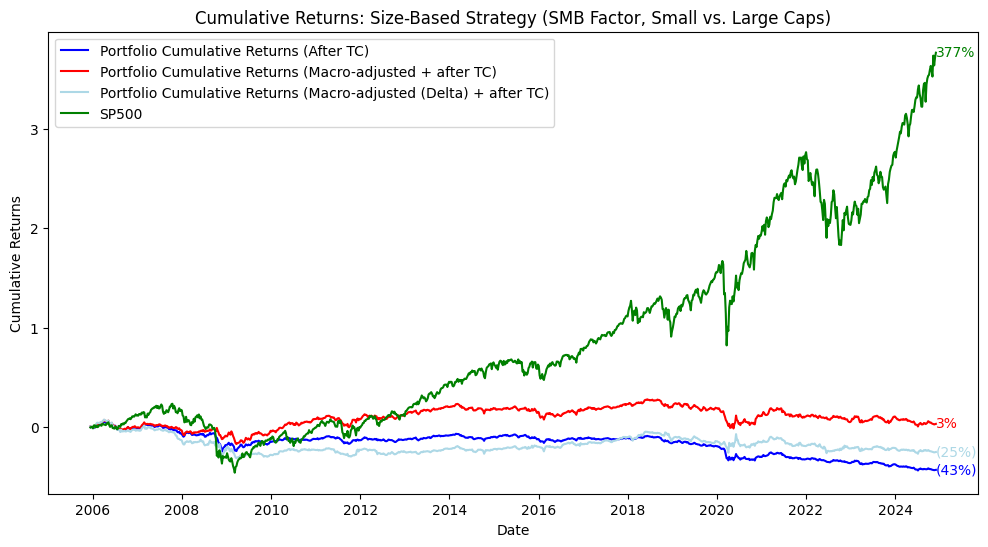

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Plotting the lines
plt.plot(portfolio_returns['Cumulative return (after TC)'], label='Portfolio Cumulative Returns (After TC)', color='blue')
plt.plot(portfolio_returns['Cumulative return (Macro-adjusted + after TC)'], label='Portfolio Cumulative Returns (Macro-adjusted + after TC)', color='red')
plt.plot(portfolio_returns['Cumulative return (Macro-adjusted (Delta) + after TC)'], label='Portfolio Cumulative Returns (Macro-adjusted (Delta) + after TC)', color='lightblue')
plt.plot(portfolio_returns['SP500_Cumulative_Returns'], label='SP500', color='green')

# Adding percentage end value labels with brackets for negatives
for column, color in zip(
    ['Cumulative return (after TC)', 'Cumulative return (Macro-adjusted + after TC)',
     'Cumulative return (Macro-adjusted (Delta) + after TC)', 'SP500_Cumulative_Returns'],
    ['blue', 'red', 'lightblue', 'green']
):
    end_value = portfolio_returns[column].iloc[-1]
    end_value_percentage = end_value * 100  # Convert to percentage

    # Format with brackets for negative values
    formatted_value = f'({abs(end_value_percentage):.0f}%)' if end_value < 0 else f'{end_value_percentage:.0f}%'

    plt.text(portfolio_returns.index[-1], end_value, formatted_value, color=color, fontsize=10, va='center')

# Adding title, labels, and legend
plt.title('Cumulative Returns: Size-Based Strategy (SMB Factor, Small vs. Large Caps)')
plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.legend()
plt.grid(False)  # Removes gridlines

plt.show()

In [40]:
stock_returns_test = weekly_returns.loc['2005-01-01':]

long_returns_marketcap = stock_returns_test.apply(
    lambda row: row[portfolios_marketcap.loc[row.name, 'Top10_long']].mean()
    if portfolios_marketcap.loc[row.name, 'Top10_long'] else 0,
    axis=1
)

short_returns_marketcap = stock_returns_test.apply(
    lambda row: -row[portfolios_marketcap.loc[row.name, 'Bottom10_short']].mean()
    if portfolios_marketcap.loc[row.name, 'Bottom10_short'] else 0,
    axis=1
)

portfolio_returns_marketcap = long_returns_marketcap / 2 + short_returns_marketcap / 2  # Transaction cost
portfolio_returns_marketcap = portfolio_returns_marketcap.fillna(0)  # Handle any missing values

portfolio_returns_marketcap = portfolio_returns_marketcap.to_frame(name='portfolio returns (before TC)')
portfolio_returns_marketcap['portfolio returns (after TC)'] = long_returns_marketcap / 2 + short_returns_marketcap / 2 - 0.00015
portfolio_returns_marketcap['Cumulative return (before TC)'] = (1 + portfolio_returns_marketcap['portfolio returns (before TC)']).cumprod() - 1
portfolio_returns_marketcap['Cumulative return (after TC)'] = (1 + portfolio_returns_marketcap['portfolio returns (after TC)']).cumprod() - 1
portfolio_returns_marketcap['Long (after TC)'] = long_returns_marketcap - 0.00015
portfolio_returns_marketcap['Long Cumulative return (after TC)'] = (1 + portfolio_returns_marketcap['Long (after TC)']).cumprod() - 1
portfolio_returns_marketcap['Short (after TC)'] = -short_returns_marketcap - 0.00015
portfolio_returns_marketcap['Short Cumulative return (after TC)'] = (1 + portfolio_returns_marketcap['Short (after TC)']).cumprod() - 1

portfolio_returns_marketcap.index = pd.to_datetime(portfolio_returns_marketcap.index)
weekly_market_returns.index = pd.to_datetime(weekly_market_returns.index)
weekly_market_returns = weekly_market_returns.rename(columns={'^GSPC': 'SP500_Returns'})
portfolio_returns_marketcap = portfolio_returns_marketcap.join(weekly_market_returns, how='left')
portfolio_returns_marketcap['SP500_Cumulative_Returns'] = (1 + portfolio_returns_marketcap['SP500_Returns']).cumprod() - 1
portfolio_returns_marketcap


,portfolio returns (before TC),portfolio returns (after TC),Cumulative return (before TC),Cumulative return (after TC),Long (after TC),Long Cumulative return (after TC),Short (after TC),Short Cumulative return (after TC),SP500_Returns,SP500_Cumulative_Returns
2005-01-02,0.006962,0.006812,0.006962,0.006812,0.011888,0.011888,-0.002035,-0.002035,0.001479,0.001479
2005-01-09,-0.016005,-0.016155,-0.009155,-0.009453,-0.047826,-0.036507,-0.015816,-0.017819,-0.021231,-0.019783
2005-01-16,-0.002064,-0.002214,-0.011200,-0.011646,-0.006421,-0.042693,-0.002293,-0.020071,-0.001408,-0.021163
2005-01-23,-0.001505,-0.001655,-0.012688,-0.013282,-0.014991,-0.057043,-0.011980,-0.031811,-0.014056,-0.034922
2005-01-30,-0.003655,-0.003805,-0.016297,-0.017037,-0.006738,-0.063397,0.000572,-0.031257,0.002988,-0.032038
...,...,...,...,...,...,...,...,...,...,...
2024-11-03,-0.004799,-0.004949,-0.325640,-0.422743,-0.018010,7.426602,-0.008413,22.166626,-0.013657,3.734037
2024-11-10,-0.002274,-0.002424,-0.327173,-0.424143,0.042137,7.781676,0.046685,23.248161,0.046561,3.954459
2024-11-17,-0.003986,-0.004136,-0.329855,-0.426524,-0.024567,7.565939,-0.016595,22.845768,-0.020835,3.851231
2024-11-24,0.002666,0.002516,-0.328068,-0.425081,0.024834,7.778662,0.019501,23.310794,0.016816,3.932809


In [41]:
portfolio_returns_marketcap

,portfolio returns (before TC),portfolio returns (after TC),Cumulative return (before TC),Cumulative return (after TC),Long (after TC),Long Cumulative return (after TC),Short (after TC),Short Cumulative return (after TC),SP500_Returns,SP500_Cumulative_Returns
2005-01-02,0.006962,0.006812,0.006962,0.006812,0.011888,0.011888,-0.002035,-0.002035,0.001479,0.001479
2005-01-09,-0.016005,-0.016155,-0.009155,-0.009453,-0.047826,-0.036507,-0.015816,-0.017819,-0.021231,-0.019783
2005-01-16,-0.002064,-0.002214,-0.011200,-0.011646,-0.006421,-0.042693,-0.002293,-0.020071,-0.001408,-0.021163
2005-01-23,-0.001505,-0.001655,-0.012688,-0.013282,-0.014991,-0.057043,-0.011980,-0.031811,-0.014056,-0.034922
2005-01-30,-0.003655,-0.003805,-0.016297,-0.017037,-0.006738,-0.063397,0.000572,-0.031257,0.002988,-0.032038
...,...,...,...,...,...,...,...,...,...,...
2024-11-03,-0.004799,-0.004949,-0.325640,-0.422743,-0.018010,7.426602,-0.008413,22.166626,-0.013657,3.734037
2024-11-10,-0.002274,-0.002424,-0.327173,-0.424143,0.042137,7.781676,0.046685,23.248161,0.046561,3.954459
2024-11-17,-0.003986,-0.004136,-0.329855,-0.426524,-0.024567,7.565939,-0.016595,22.845768,-0.020835,3.851231
2024-11-24,0.002666,0.002516,-0.328068,-0.425081,0.024834,7.778662,0.019501,23.310794,0.016816,3.932809


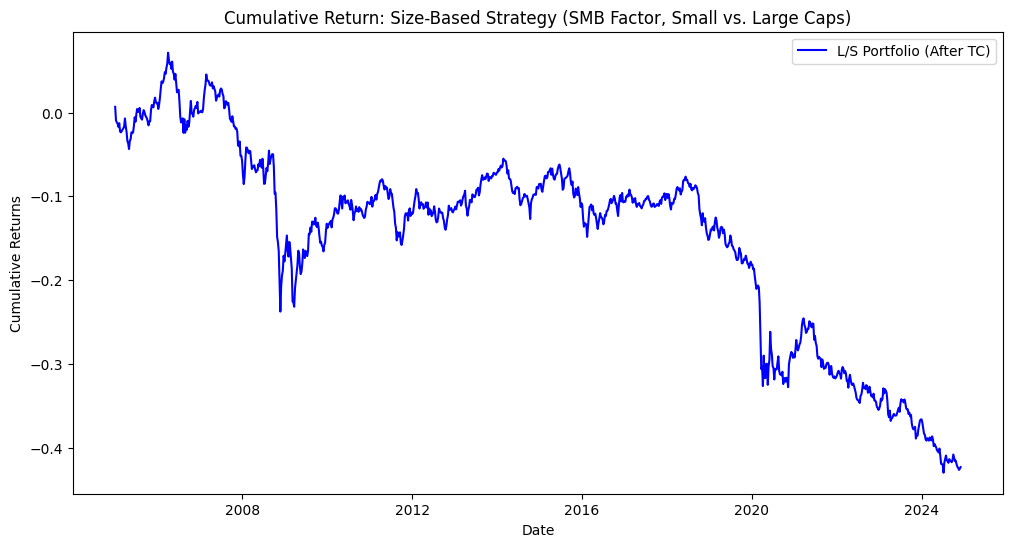

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Plotting the lines
plt.plot(portfolio_returns_marketcap['Cumulative return (after TC)'], label='L/S Portfolio (After TC)', color='blue')
#plt.plot(portfolio_returns_marketcap['SP500_Cumulative_Returns'], label='SP500', color='green')


# Adding title, labels, and legend
plt.title('Cumulative Return: Size-Based Strategy (SMB Factor, Small vs. Large Caps)')
plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.legend()
plt.grid(False)  # Removes gridlines

plt.show()


In [43]:
# Function to calculate performance metrics
def calculate_metrics(returns, risk_free_rate):
    # Annualized Volatility
    volatility = returns.std() * np.sqrt(252)
    # Annualized Average Excess Return
    excess_returns = returns - risk_free_rate
    average_excess_return = excess_returns.mean() * 252
    # Sharpe Ratio
    sharpe_ratio = average_excess_return / volatility
    # Winning Days
    winning_days = (returns > 0).sum()
    # Losing Days
    losing_days = (returns < 0).sum()
    return volatility, average_excess_return, sharpe_ratio, int(winning_days), int(losing_days)

# Calculate metrics for portfolio returns
portfolio_metrics = calculate_metrics(
    portfolio_returns_marketcap['portfolio returns (after TC)'],
    0.00016
)

# Calculate metrics for SP500 returns
sp500_metrics = calculate_metrics(
    portfolio_returns_marketcap['SP500_Returns'],
    0.00016
)

# Create a DataFrame to store the results
performance_metrics_marketcap = pd.DataFrame({
    'Metric': ['Volatility', 'Average Excess Return', 'Sharpe Ratio', 'Winning Days', 'Losing Days'],
    'Portfolio (B/M)': portfolio_metrics,
    'S&P 500': sp500_metrics
})

# Display the performance metrics DataFrame
performance_metrics_marketcap


,Metric,Portfolio (B/M),S&P 500
0,Volatility,0.145833,0.386096
1,Average Excess Return,-0.163000,0.424520
2,Sharpe Ratio,-1.117715,1.099519
3,Winning Days,508.000000,598.000000
4,Losing Days,532.000000,442.000000


## Factor: Betting Against Beta

In [44]:
# Step 1: Use the existing `stock_returns` DataFrame as `returns`
# Ensure stock_returns is calculated correctly
#stock_returns = closing_prices.pct_change().dropna()  # Use the `closing_prices` DataFrame for daily returns

# Step 2: Use `aligned_data` to calculate market excess returns
# If `aligned_data` isn't defined, ensure it's calculated as shown in your file
market_excessreturn = market_data["Excess_Returns"]
market_excessreturn.index = pd.to_datetime(market_excessreturn.index)
stock_returns.index = pd.to_datetime(stock_returns.index)

# Step 3: Calculate rolling beta
beta = pd.DataFrame(index=stock_returns.index)  # Initialize an empty DataFrame for betas

window_size = 252 # Example: 1 year of daily returns

# Loop through each ticker to calculate rolling beta
for ticker in tickers:
    if ticker in stock_returns.columns:
        # Align stock returns and market excess returns
        aligned_data = pd.concat([stock_returns[ticker], market_excessreturn], axis=1).dropna()
        aligned_data.columns = ['Stock_Returns', 'Market_Excess_Returns']

        # Calculate rolling covariance and variance
        rolling_covariance = aligned_data['Stock_Returns'].rolling(window=window_size).cov(
            aligned_data['Market_Excess_Returns']
        )
        rolling_variance = aligned_data['Market_Excess_Returns'].rolling(window=window_size).var()

        # Compute rolling beta
        beta[ticker] = rolling_covariance / rolling_variance

# Fill missing values for clean output
beta = beta.ffill().bfill()

# Step 4: Save or display results
beta.tail()



/var/folders/rc/wvtm06wn1h14bk35mggcx26w0000gn/T/ipykernel_26120/4154691892.py:30: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  beta[ticker] = rolling_covariance / rolling_variance
/var/folders/rc/wvtm06wn1h14bk35mggcx26w0000gn/T/ipykernel_26120/4154691892.py:30: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  beta[ticker] = rolling_covariance / rolling_variance
/var/folders/rc/wvtm06wn1h14bk35mggcx26w0000gn/T/ipykernel_26120/4154691892.py:30: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of call

,MMM,AOS,ABT,ABBV,ACN,ADBE,AMD,AES,AFL,A,...,WMB,WTW,WDAY,WYNN,XEL,XYL,YUM,ZBRA,ZBH,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2024-11-22,0.371851,0.457214,0.046494,0.165267,0.387280,0.654894,1.171120,0.562525,0.274892,0.504160,...,0.323927,0.236623,0.339678,0.459269,0.119835,0.599365,0.276216,0.821016,0.278226,0.260016
2024-11-25,0.372876,0.459529,0.046245,0.164821,0.387764,0.654929,1.171735,0.563080,0.275342,0.504828,...,0.320221,0.236231,0.337551,0.462334,0.119471,0.600866,0.276803,0.821478,0.278344,0.261321
2024-11-26,0.381166,0.457726,0.044235,0.171991,0.387655,0.658061,1.162017,0.553745,0.278545,0.520922,...,0.320497,0.238725,0.337808,0.456579,0.118048,0.592170,0.275882,0.823998,0.276648,0.255232
2024-11-27,0.384702,0.457481,0.042717,0.168370,0.388767,0.662943,1.161976,0.543627,0.279396,0.511633,...,0.319640,0.234886,0.315574,0.457226,0.115270,0.590750,0.274193,0.821369,0.272640,0.251808
2024-11-29,0.384078,0.456982,0.044255,0.167978,0.389550,0.659636,1.163324,0.544152,0.277697,0.514900,...,0.319743,0.236293,0.314759,0.464746,0.111380,0.591043,0.272180,0.820796,0.273568,0.247302


In [45]:
stock_returns

Ticker,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-03,-0.085714,0.067342,NaN,NaN,-0.007092,-0.093596,NaN,-0.025093,-0.035428,0.000000,...,-0.016711,NaN,-0.031847,-0.014937,NaN,NaN,-0.032415,NaN,-0.034815,NaN
2000-01-04,-0.023853,-0.053117,NaN,NaN,-0.012704,0.005494,NaN,-0.046627,-0.043296,0.005291,...,-0.035842,NaN,0.019672,-0.007270,NaN,NaN,-0.011824,NaN,-0.014428,NaN
2000-01-05,-0.058491,0.002410,NaN,NaN,0.011173,0.081081,NaN,0.051502,0.014599,-0.015789,...,0.052974,NaN,0.038585,0.038462,NaN,NaN,0.000000,NaN,0.066588,NaN
2000-01-06,-0.026369,-0.104830,NaN,NaN,0.033088,-0.010000,NaN,0.005086,-0.027338,0.010753,...,0.041264,NaN,-0.006211,0.056589,NaN,NaN,-0.001712,NaN,-0.041970,NaN
2000-01-07,0.100529,0.031088,NaN,NaN,0.028986,0.055556,NaN,0.051777,0.034226,0.005263,...,-0.005204,NaN,0.000000,-0.011636,NaN,NaN,-0.022298,NaN,-0.006455,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-11-22,0.013172,0.007936,0.014971,0.030308,0.004607,0.010850,0.001172,0.019204,0.014418,0.000942,...,0.014286,-0.004037,-0.004048,-0.000246,0.005787,-0.003779,0.005501,0.014263,0.007381,0.003459
2024-11-25,-0.000297,0.006092,0.000226,0.021158,-0.001268,0.001501,0.003583,-0.000694,0.026821,0.001133,...,0.020583,0.020754,-0.002091,-0.012023,0.011850,-0.018919,0.006019,0.002258,0.002275,0.009661
2024-11-26,0.057865,0.007414,0.022870,-0.007885,-0.005732,0.003097,0.003287,0.010289,-0.056429,0.011676,...,-0.005609,-0.013001,-0.002498,-0.013051,-0.029079,-0.009183,-0.002662,-0.009312,0.000025,-0.015410


In [46]:
# Step 1: Rank stocks by beta
# Lower beta gets higher rank as we want to long low beta and short high beta
ranked_beta = beta.rank(axis=1, ascending=True, method='min')  # Smaller beta gets higher rank

# Step 2: Define Long and Short Groups (Lowest 10% and Highest 10% Beta)
top_10_percentile = ranked_beta.quantile(0.1, axis=1)  # Threshold for the lowest 10%
bottom_10_percentile = ranked_beta.quantile(0.9, axis=1)  # Threshold for the highest 10%

# Long portfolio: Low-beta stocks (beta <= 10th percentile)
long_beta = ranked_beta.apply(lambda row: row[row <= top_10_percentile[row.name]].index.tolist(), axis=1)

# Short portfolio: High-beta stocks (beta >= 90th percentile)
short_beta = ranked_beta.apply(lambda row: row[row >= bottom_10_percentile[row.name]].index.tolist(), axis=1)

# Step 3: Create a DataFrame to store the portfolios
portfolios_beta = pd.DataFrame(index=beta.index, columns=['Long_LowBeta', 'Short_HighBeta'])
portfolios_beta['Long_LowBeta'] = long_beta
portfolios_beta['Short_HighBeta'] = short_beta

# Step 4: Save or display the portfolio results
# portfolios_beta.to_csv('beta_long_short_portfolios.csv')

# Display the resulting portfolio data
print(portfolios_beta.head())



                                                 Long_LowBeta  \
Date                                                            
2000-01-03  [AMCR, AEE, AWK, ARES, XYZ, BR, CPB, CARR, CBO...   
2000-01-04  [AMCR, AEE, AWK, ARES, XYZ, BR, CPB, CARR, CBO...   
2000-01-05  [AMCR, AEE, AWK, ARES, XYZ, BR, CPB, CARR, CBO...   
2000-01-06  [AMCR, AEE, AWK, ARES, XYZ, BR, CPB, CARR, CBO...   
2000-01-07  [AMCR, AEE, AWK, ARES, XYZ, BR, CPB, CARR, CBO...   

                                               Short_HighBeta  
Date                                                           
2000-01-03  [AMD, AKAM, AXON, CHRW, CBRE, SCHW, CIEN, CTSH...  
2000-01-04  [AMD, AKAM, AXON, CHRW, CBRE, SCHW, CIEN, CTSH...  
2000-01-05  [AMD, AKAM, AXON, CHRW, CBRE, SCHW, CIEN, CTSH...  
2000-01-06  [AMD, AKAM, AXON, CHRW, CBRE, SCHW, CIEN, CTSH...  
2000-01-07  [AMD, AKAM, AXON, CHRW, CBRE, SCHW, CIEN, CTSH...  


In [47]:
factor_scores = pd.read_excel("Factor.xlsm")


factor_scores['date'] = pd.to_datetime(factor_scores['date'])  # Ensure 'date' is in datetime format
factor_scores.set_index('date', inplace=True)  # Set 'date' as the index

# Generate a daily date range covering the full period
daily_index = pd.date_range(start='2005-01-01', end='2024-12-31', freq='D')

# Backfill first to assign each month's last value to earlier dates
# Then reindex to daily, ensuring January gets the value of January 31
monthly_factor_scores = factor_scores.resample('ME').ffill()
daily_factor_scores = monthly_factor_scores.resample('D').bfill()

# Reset the index for integration with other datasets
daily_factor_scores = daily_factor_scores.reindex(daily_index, method='bfill').reset_index()

# Rename columns for clarity
daily_factor_scores.rename(columns={'index': 'date'}, inplace=True)

daily_factor_scores['regime'] = daily_factor_scores['z-score'].apply(
    lambda x: 'expansion' if x > 0 else ('contraction' if x < -0.5 else 'neutral')
)

daily_factor_scores.index = daily_factor_scores.date
daily_factor_scores.index = pd.to_datetime(daily_factor_scores.index)

daily_factor_scores['prev_regime'] = daily_factor_scores['regime'].shift(1)

daily_factor_scores['long_weight'] = daily_factor_scores['prev_regime'].apply(lambda x: 1.2 if x=='expansion' else (0.8 if x=='contraction' else 1.0))
daily_factor_scores['short_weight'] = daily_factor_scores['prev_regime'].apply(lambda x: 0.8 if x=='expansion' else (1.2 if x=='contraction' else 1.0))

daily_factor_scores.head()

,date,factor,square,vol,z-score,regime,prev_regime,long_weight,short_weight
date,,,,,,,,,
2005-01-01,2005-01-01,0.502212,0.252217,0.502212,1.0,expansion,NaN,1.0,1.0
2005-01-02,2005-01-02,0.502212,0.252217,0.502212,1.0,expansion,expansion,1.2,0.8
2005-01-03,2005-01-03,0.502212,0.252217,0.502212,1.0,expansion,expansion,1.2,0.8
2005-01-04,2005-01-04,0.502212,0.252217,0.502212,1.0,expansion,expansion,1.2,0.8
2005-01-05,2005-01-05,0.502212,0.252217,0.502212,1.0,expansion,expansion,1.2,0.8


In [48]:
# Calculate long and short returns

stock_returns_test = stock_returns.loc['2005-01-01':]

long_returns_delta = stock_returns_test.apply(
    lambda row: row[portfolios_beta.loc[row.name, 'Long_LowBeta']].mean()*daily_factor_scores_delta.loc[row.name,'long_weight']
    if portfolios_beta.loc[row.name, 'Long_LowBeta'] else 0,
    axis=1
)

short_returns_delta = stock_returns_test.apply(
    lambda row: -row[portfolios_beta.loc[row.name, 'Short_HighBeta']].mean()*daily_factor_scores_delta.loc[row.name,'short_weight']
    if portfolios_beta.loc[row.name, 'Short_HighBeta'] else 0,
    axis=1
)

long_returns_macro = stock_returns_test.apply(
    lambda row: row[portfolios_beta.loc[row.name, 'Long_LowBeta']].mean()*daily_factor_scores.loc[row.name,'long_weight']
    if portfolios_beta.loc[row.name, 'Long_LowBeta'] else 0,
    axis=1
)

short_returns_macro = stock_returns_test.apply(
    lambda row: -row[portfolios_beta.loc[row.name, 'Short_HighBeta']].mean()*daily_factor_scores.loc[row.name,'short_weight']
    if portfolios_beta.loc[row.name, 'Short_HighBeta'] else 0,
    axis=1
)

long_returns = stock_returns_test.apply(
    lambda row: row[portfolios_beta.loc[row.name, 'Long_LowBeta']].mean()
    if portfolios_beta.loc[row.name, 'Long_LowBeta'] else 0,
    axis=1
)

short_returns = stock_returns_test.apply(
    lambda row: -row[portfolios_beta.loc[row.name, 'Short_HighBeta']].mean()
    if portfolios_beta.loc[row.name, 'Short_HighBeta'] else 0,
    axis=1
)

portfolio_returns = long_returns/2 - short_returns/2 #transaction cost
portfolio_returns = portfolio_returns.fillna(0)  # Handle any missing values

portfolio_returns = portfolio_returns.to_frame(name='portfolio returns (before TC)')
portfolio_returns['portfolio returns (after TC)'] = long_returns/2 + short_returns/2 - 0.00015
portfolio_returns['portfolio returns (Macro-adjusted + after TC)'] = long_returns_macro/2 + short_returns_macro/2 - 0.00015
portfolio_returns['portfolio returns (Macro-adjusted (Delta) + after TC)'] = long_returns_delta/2 + short_returns_delta/2 - 0.00015
portfolio_returns['Cumulative return (before TC)'] = (1 + portfolio_returns['portfolio returns (before TC)']).cumprod() - 1
portfolio_returns['Cumulative return (after TC)'] = (1 + portfolio_returns['portfolio returns (after TC)']).cumprod() - 1
portfolio_returns['Cumulative return (Macro-adjusted + after TC)'] = (1 + portfolio_returns['portfolio returns (Macro-adjusted + after TC)']).cumprod() - 1
portfolio_returns['Cumulative return (Macro-adjusted (Delta) + after TC)'] = (1 + portfolio_returns['portfolio returns (Macro-adjusted (Delta) + after TC)']).cumprod() - 1
portfolio_returns.index = pd.to_datetime(portfolio_returns.index)
market_data.index = pd.to_datetime(market_data.index)

portfolio_returns = portfolio_returns.join(market_data, how='inner')

portfolio_returns['SP500_Cumulative_Returns'] = (1 + portfolio_returns['SP500_Returns']).cumprod() - 1

portfolio_returns

,portfolio returns (before TC),portfolio returns (after TC),portfolio returns (Macro-adjusted + after TC),portfolio returns (Macro-adjusted (Delta) + after TC),Cumulative return (before TC),Cumulative return (after TC),Cumulative return (Macro-adjusted + after TC),Cumulative return (Macro-adjusted (Delta) + after TC),SP500_Returns,Risk_Free_Rate,Excess_Returns,SP500_Cumulative_Returns
Date,,,,,,,,,,,,
2005-12-07,-0.008082,0.002138,0.000522,0.003754,0.023650,-0.029325,-0.010179,-0.022995,-0.005009,0.000156,-0.005165,-0.005009
2005-12-08,-0.000183,-0.000695,-0.000732,-0.000659,0.023463,-0.029999,-0.010904,-0.023638,-0.001217,0.000153,-0.001369,-0.006220
2005-12-09,0.004310,-0.001442,-0.000580,-0.002304,0.027874,-0.031398,-0.011478,-0.025888,0.002811,0.000152,0.002658,-0.003426
2005-12-12,-0.002290,-0.000150,-0.000608,0.000308,0.025519,-0.031544,-0.012079,-0.025588,0.000842,0.000152,0.000690,-0.002588
2005-12-13,0.005092,0.002953,0.003971,0.001934,0.030741,-0.028684,-0.008156,-0.023703,0.005554,0.000152,0.005402,0.002952
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-11-22,0.006328,-0.005708,-0.005708,-0.005708,2.611908,-0.617484,-0.506010,-0.634078,0.003468,0.000175,0.003293,3.725876
2024-11-25,-0.003795,0.002773,0.002773,0.002773,2.598202,-0.616424,-0.504641,-0.633063,0.003020,0.000175,0.002846,3.740151
2024-11-26,-0.002063,0.006294,0.006294,0.006294,2.590777,-0.614009,-0.501523,-0.630754,0.005722,0.000174,0.005548,3.767274


In [49]:
print(portfolio_returns.columns)

Index(['portfolio returns (before TC)', 'portfolio returns (after TC)',
       'portfolio returns (Macro-adjusted + after TC)',
       'portfolio returns (Macro-adjusted (Delta) + after TC)',
       'Cumulative return (before TC)', 'Cumulative return (after TC)',
       'Cumulative return (Macro-adjusted + after TC)',
       'Cumulative return (Macro-adjusted (Delta) + after TC)',
       'SP500_Returns', 'Risk_Free_Rate', 'Excess_Returns',
       'SP500_Cumulative_Returns'],
      dtype='str')


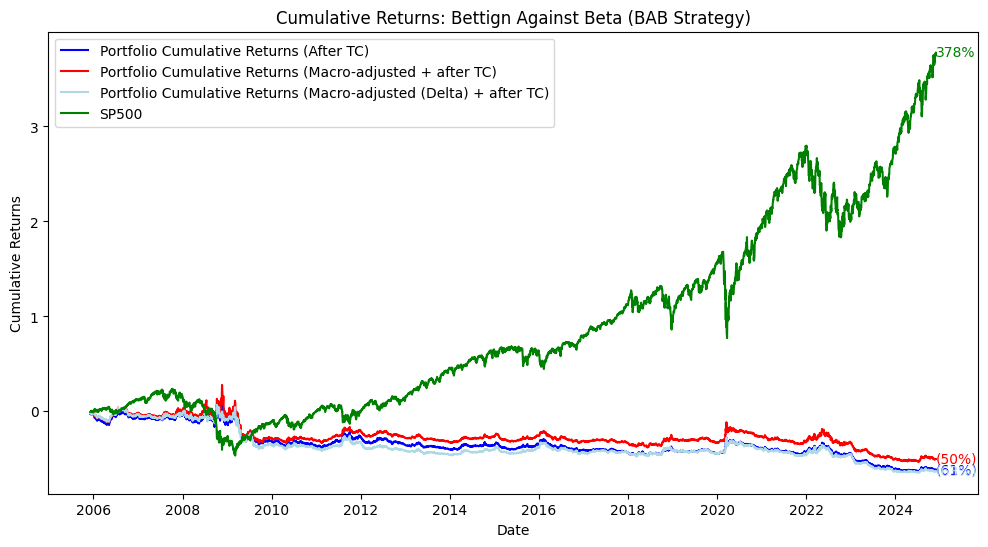

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Plotting the lines
plt.plot(portfolio_returns['Cumulative return (after TC)'], label='Portfolio Cumulative Returns (After TC)', color='blue')
plt.plot(portfolio_returns['Cumulative return (Macro-adjusted + after TC)'], label='Portfolio Cumulative Returns (Macro-adjusted + after TC)', color='red')
plt.plot(portfolio_returns['Cumulative return (Macro-adjusted (Delta) + after TC)'], label='Portfolio Cumulative Returns (Macro-adjusted (Delta) + after TC)', color='lightblue')
# Uncomment SP500 line if needed
plt.plot(portfolio_returns['SP500_Cumulative_Returns'], label='SP500', color='green')

# Adding percentage end value labels with brackets for negatives
for column, color in zip(
    ['Cumulative return (after TC)', 'Cumulative return (Macro-adjusted + after TC)',
     'Cumulative return (Macro-adjusted (Delta) + after TC)', 'SP500_Cumulative_Returns'],
    ['blue', 'red', 'lightblue', 'green']
):
    end_value = portfolio_returns[column].iloc[-1]
    end_value_percentage = end_value * 100  # Convert to percentage

    # Format with brackets for negative values
    formatted_value = f'({abs(end_value_percentage):.0f}%)' if end_value < 0 else f'{end_value_percentage:.0f}%'

    plt.text(portfolio_returns.index[-1], end_value, formatted_value, color=color, fontsize=10, va='center')

# Adding title, labels, and legend
plt.title('Cumulative Returns: Bettign Against Beta (BAB Strategy)')
plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.legend()
plt.grid(False)  # Removes gridlines

plt.show()

In [51]:
# Calculate long and short returns

stock_returns_test = stock_returns.loc['2005-01-01':]

long_returns = stock_returns_test.apply(
    lambda row: row[portfolios_beta.loc[row.name, 'Long_LowBeta']].mean()
    if portfolios_beta.loc[row.name, 'Long_LowBeta'] else 0,
    axis=1
)

short_returns = stock_returns_test.apply(
    lambda row: -row[portfolios_beta.loc[row.name, 'Short_HighBeta']].mean()
    if portfolios_beta.loc[row.name, 'Short_HighBeta'] else 0,
    axis=1
)

portfolio_returns = long_returns/2 + short_returns/2 #transaction cost
portfolio_returns = portfolio_returns.fillna(0)  # Handle any missing values

portfolio_returns = portfolio_returns.to_frame(name='portfolio returns (before TC)')
portfolio_returns['portfolio returns (after TC)'] = long_returns/2 + short_returns/2 - 0.00015
portfolio_returns['Cumulative return (before TC)'] = (1 + portfolio_returns['portfolio returns (before TC)']).cumprod() - 1
portfolio_returns['Cumulative return (after TC)'] = (1 + portfolio_returns['portfolio returns (after TC)']).cumprod() - 1
portfolio_returns['Long (after TC)'] = long_returns - 0.00015
portfolio_returns['Long Cumulative return (after TC)'] = (1 + portfolio_returns['Long (after TC)']).cumprod() - 1
portfolio_returns['Short (after TC)'] = -short_returns - 0.00015
portfolio_returns['Short Cumulative return (after TC)'] = (1 + portfolio_returns['Short (after TC)']).cumprod() - 1

portfolio_returns.index = pd.to_datetime(portfolio_returns.index)
market_data.index = pd.to_datetime(market_data.index)

portfolio_returns = portfolio_returns.join(market_data, how='inner')

portfolio_returns['SP500_Cumulative_Returns'] = (1 + portfolio_returns['SP500_Returns']).cumprod() - 1

In [52]:
portfolio_returns

,portfolio returns (before TC),portfolio returns (after TC),Cumulative return (before TC),Cumulative return (after TC),Long (after TC),Long Cumulative return (after TC),Short (after TC),Short Cumulative return (after TC),SP500_Returns,Risk_Free_Rate,Excess_Returns,SP500_Cumulative_Returns
Date,,,,,,,,,,,,
2005-12-07,2.288141e-03,0.002138,0.005655,-0.029325,-0.005943,-0.000684,-0.010520,-0.027325,-0.005009,0.000156,-0.005165,-0.005009
2005-12-08,-5.452210e-04,-0.000695,0.005107,-0.029999,-0.000879,-0.001562,0.000212,-0.027119,-0.001217,0.000153,-0.001369,-0.006220
2005-12-09,-1.292180e-03,-0.001442,0.003808,-0.031398,0.002868,0.001302,0.005452,-0.021815,0.002811,0.000152,0.002658,-0.003426
2005-12-12,-1.596164e-07,-0.000150,0.003808,-0.031544,-0.002441,-0.001142,-0.002440,-0.024202,0.000842,0.000152,0.000690,-0.002588
2005-12-13,3.102686e-03,0.002953,0.006922,-0.028684,0.008044,0.006893,0.001839,-0.022407,0.005554,0.000152,0.005402,0.002952
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-11-22,-5.558262e-03,-0.005708,-0.189148,-0.617484,0.000619,1.071083,0.011736,-0.039924,0.003468,0.000175,0.003293,3.725876
2024-11-25,2.922683e-03,0.002773,-0.186778,-0.616424,-0.001022,1.068966,-0.006867,-0.046517,0.003020,0.000175,0.002846,3.740151
2024-11-26,6.444142e-03,0.006294,-0.181537,-0.614009,0.004231,1.077719,-0.008658,-0.054772,0.005722,0.000174,0.005548,3.767274


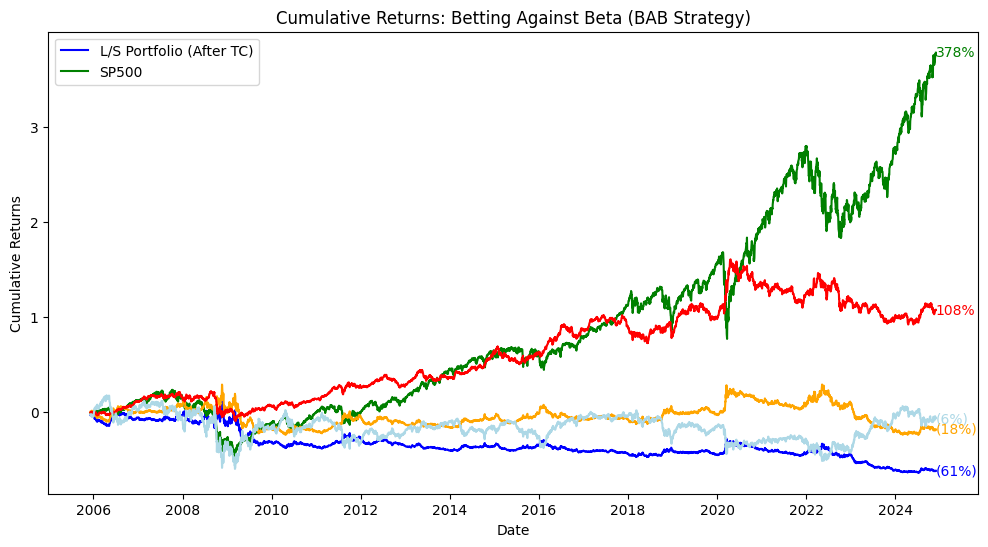

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Plotting the lines
plt.plot(portfolio_returns['Cumulative return (after TC)'], label='L/S Portfolio (After TC)', color='blue')
plt.plot(portfolio_returns['SP500_Cumulative_Returns'], label='SP500', color='green')
plt.plot(portfolio_returns['Cumulative return (before TC)'], color='orange')
plt.plot(portfolio_returns['Long Cumulative return (after TC)'], color='red')
plt.plot(portfolio_returns['Short Cumulative return (after TC)'], color='lightblue')

# Adding percentage end value labels with brackets for negatives
for column, color in zip(
    ['Cumulative return (before TC)', 'Cumulative return (after TC)',
     'Long Cumulative return (after TC)', 'Short Cumulative return (after TC)',
     'SP500_Cumulative_Returns'],
    ['orange', 'blue', 'red', 'lightblue', 'green']
):
    end_value = portfolio_returns[column].iloc[-1]
    end_value_percentage = end_value * 100  # Convert to percentage

    # Format with brackets for negative values
    formatted_value = f'({abs(end_value_percentage):.0f}%)' if end_value < 0 else f'{end_value_percentage:.0f}%'

    plt.text(portfolio_returns.index[-1], end_value,
             formatted_value,
             color=color, fontsize=10, va='center')

plt.title('Cumulative Returns: Betting Against Beta (BAB Strategy)')

plt.xlabel('Date')

plt.ylabel('Cumulative Returns')

plt.legend(loc='upper left') 

plt.grid(False)

plt.show()